# Spanish Imbalance Price - Quantile Regression 2H prediction
## Exploratory Data Analysis

NB: This EDA only serves to understand the data, as in this EDA some features are not correct. Like the actuals which should have a 2h information lag + 2h prediction lag

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.data.loader import load_parquet, energy_data, processed_energy_data
from src.utils.plots import plot_distribution_over_time, plot_top_correlated_features, plot_acf_pacf, missing_summary



from statsmodels.tsa.stattools import pacf
import warnings

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
data = load_parquet(energy_data)

print(f"Data Shape : {data.shape}")
data.head(5)

Data Shape : (40696, 44)


,Day_Ahead_Price,Long_Imbalance_Price,Short_Imbalance_Price,Forecasted_Load,Actual_Load,Forecast_Scheduled_Aggregated,Forecast_Scheduled_Consumption,Day_ahead_Forecast_Solar,Day_ahead_Forecast_Wind_Onshore,Intraday_Forecast_Solar,...,scheduled_exchange_ES>FR,scheduled_exchange_FR>ES,Net_scheduled_exchange_ES-FR,ntc_ES>FR,ntc_FR>ES,scheduled_exchange_ES>PT,scheduled_exchange_PT>ES,Net_scheduled_exchange_ES-PT,ntc_ES>PT,ntc_PT>ES
2025-01-01 00:00:00+00:00,131.59,150.22,150.22,22727.0,22712.0,20474.4,0.0,29.0,2939.0,1.0,...,0.0,2341.0,2341.0,3700.0,2341.0,2263.2,0.0,-2263.2,3870.0,3105.0
2025-01-01 00:15:00+00:00,131.59,140.58,140.58,22519.0,22540.0,20474.4,0.0,29.0,2976.0,1.0,...,0.0,2341.0,2341.0,3700.0,2341.0,2263.2,0.0,-2263.2,3870.0,3105.0
2025-01-01 00:30:00+00:00,131.59,87.51,87.51,22267.0,22312.0,20474.4,0.0,30.0,3010.0,1.0,...,0.0,2341.0,2341.0,3700.0,2341.0,2263.2,0.0,-2263.2,3870.0,3105.0
2025-01-01 00:45:00+00:00,131.59,79.70,79.70,21978.0,22020.0,20474.4,0.0,30.0,3041.0,1.0,...,0.0,2341.0,2341.0,3700.0,2341.0,2263.2,0.0,-2263.2,3870.0,3105.0
2025-01-01 01:00:00+00:00,131.49,95.19,141.46,21690.0,21688.0,19205.6,64.4,31.0,3072.0,0.0,...,0.0,2341.0,2341.0,3700.0,2341.0,2460.8,0.0,-2460.8,3870.0,3105.0


---
## 1. Dataset Overview

In [5]:
print("Columns types: ")
print(data.dtypes.to_string())
print()
data.describe()

Columns types: 
Day_Ahead_Price                                      float64
Long_Imbalance_Price                                 float64
Short_Imbalance_Price                                float64
Forecasted_Load                                      float64
Actual_Load                                          float64
Forecast_Scheduled_Aggregated                        float64
Forecast_Scheduled_Consumption                       float64
Day_ahead_Forecast_Solar                             float64
Day_ahead_Forecast_Wind_Onshore                      float64
Intraday_Forecast_Solar                              float64
Intraday_Forecast_Wind_Onshore                       float64
Biomass_Actual_Aggregated                            float64
Energy_storage_Actual_Aggregated                     float64
Energy_storage_Actual_Consumption                    float64
Fossil_Brown_coal/Lignite_Actual_Aggregated          float64
Fossil_Coal-derived_gas_Actual_Aggregated            float64
Fossil_G

,Day_Ahead_Price,Long_Imbalance_Price,Short_Imbalance_Price,Forecasted_Load,Actual_Load,Forecast_Scheduled_Aggregated,Forecast_Scheduled_Consumption,Day_ahead_Forecast_Solar,Day_ahead_Forecast_Wind_Onshore,Intraday_Forecast_Solar,...,scheduled_exchange_ES>FR,scheduled_exchange_FR>ES,Net_scheduled_exchange_ES-FR,ntc_ES>FR,ntc_FR>ES,scheduled_exchange_ES>PT,scheduled_exchange_PT>ES,Net_scheduled_exchange_ES-PT,ntc_ES>PT,ntc_PT>ES
count,40696.000000,40696.000000,40696.000000,40696.000000,40696.000000,40504.000000,40504.000000,40696.000000,39928.000000,40600.000000,...,40696.000000,40696.000000,40696.000000,40696.000000,40696.000000,40696.000000,40696.000000,40696.000000,40696.000000,40696.000000
mean,62.520367,40.692181,70.860681,27526.917903,27499.534107,31276.992860,1032.006044,5652.413775,6993.046960,5702.369975,...,1352.826450,1239.491220,-113.335230,2451.873894,2622.294550,1253.590205,310.294456,-943.295749,3497.654954,3059.371142
std,47.884605,49.985880,51.993741,4517.635248,4548.642065,6134.056696,1278.384749,6998.463532,4194.812987,7054.404600,...,1161.962549,1125.559509,2036.447693,812.437494,721.685803,1254.448973,644.381137,1663.385876,1051.931775,717.154209
min,-15.000000,-1863.670000,-626.710000,17917.000000,10536.000000,0.000000,0.000000,0.000000,468.000000,0.000000,...,0.000000,0.000000,-3932.700000,0.000000,300.000000,0.000000,0.000000,-5034.600000,0.000000,0.000000
25%,15.225000,-0.020000,28.660000,23805.000000,23796.000000,26424.800000,0.000000,85.000000,3662.000000,67.000000,...,220.175000,193.275000,-2000.000000,2000.000000,2200.000000,0.000000,0.000000,-2235.825000,3105.000000,2829.000000
50%,65.370000,37.580000,82.875000,27462.500000,27428.000000,31023.600000,246.800000,584.000000,6146.000000,614.000000,...,1117.100000,988.700000,-226.100000,2544.000000,2775.000000,979.400000,0.000000,-979.400000,3780.000000,3194.000000
75%,102.000000,77.882500,105.652500,30962.250000,30968.000000,35993.600000,2041.200000,12016.250000,9608.000000,12117.000000,...,2450.000000,2248.900000,1697.075000,3006.000000,3191.000000,2235.825000,251.600000,251.600000,4185.000000,3465.000000
max,240.000000,352.180000,1488.160000,40871.000000,41388.000000,49824.800000,4588.800000,24072.000000,19204.000000,24141.000000,...,5599.600000,5482.700000,3930.500000,4024.000000,3977.000000,5034.600000,4410.000000,4410.000000,5310.000000,4950.000000


---
## 2. Target Variables - Long_Imbalance_Price | Short_Imbalance_Price

In [6]:
targets = ["Long_Imbalance_Price", "Short_Imbalance_Price"]
data["Month_year"] = data.index.strftime("%b-%Y")
data["hour"] = data.index.strftime("%H")

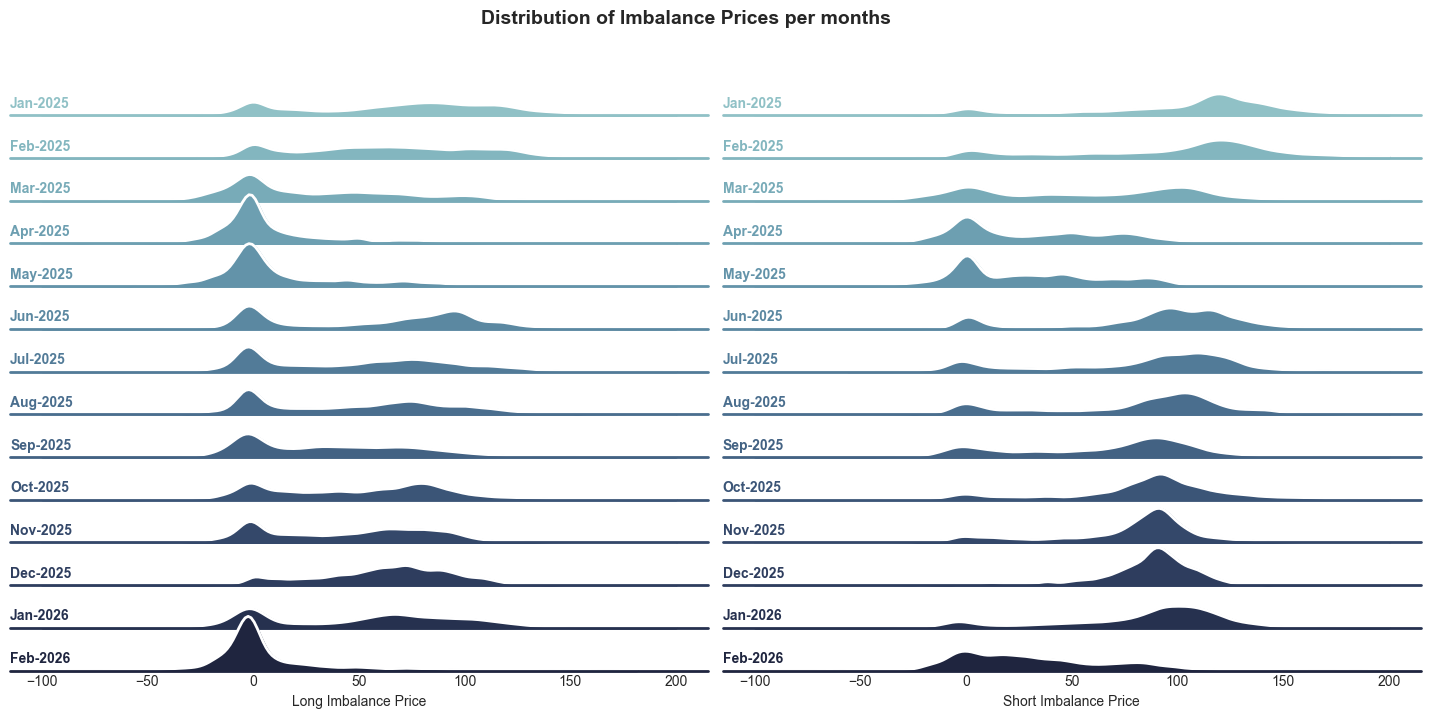

In [7]:
plot_distribution_over_time(data=data,
                            targets=targets,
                            by="Month_year",
                            title="Distribution of Imbalance Prices per months")

* We see a fairly radical change in distribution depending on the month
* Some months exhibit a bimodal distribution, bimodality may be because of hours, and week days and week ends

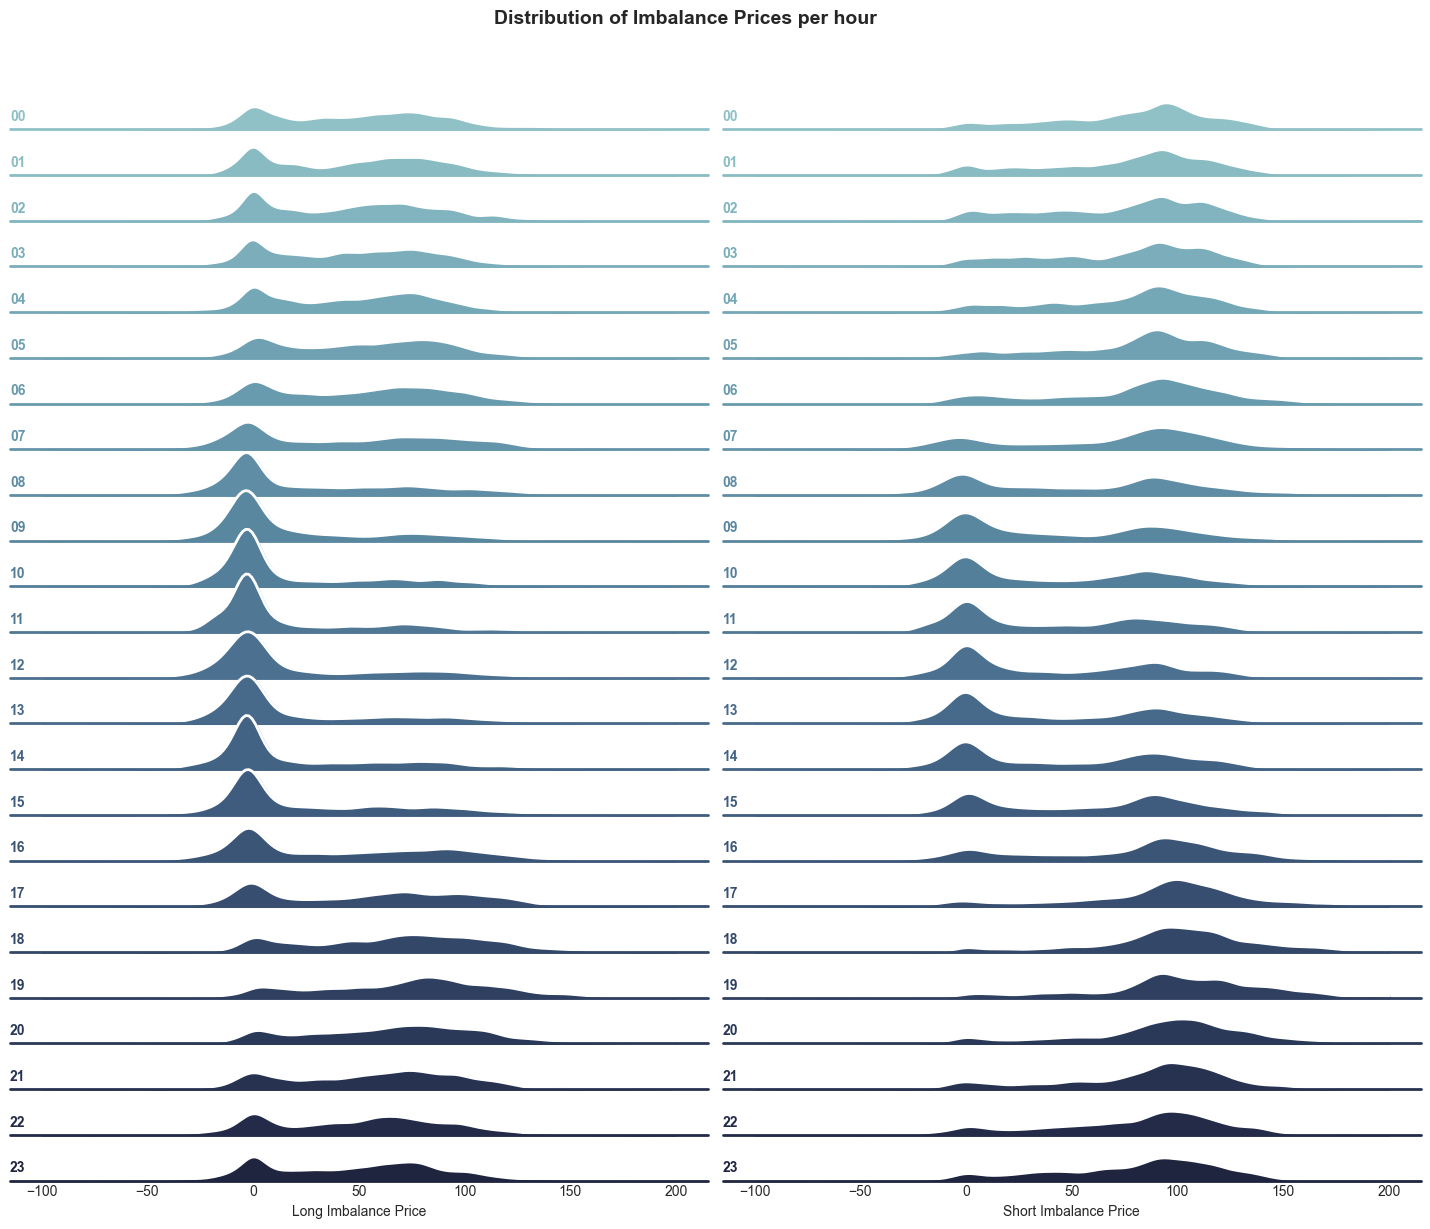

In [8]:
plot_distribution_over_time(data=data,
                            targets=targets,
                            by="hour",
                            title="Distribution of Imbalance Prices per hour")

* The distribution also varies according to the time of day, peak hours (8h00-15h00) are more concentrated for Long Imbalance Price, off-peak hours are more spread out, while it's the inverse for Short Imbalance Price

---
## 3. Missing Values Analysis

In [9]:
data_miss = missing_summary(data, "Data")

print(f"Data - columns with missing values: {len(data_miss)}")
data_miss

Data - columns with missing values: 28


,Missing,Missing (%)
Data — Column,,
Energy_storage_Actual_Aggregated,29041,71.36
Energy_storage_Actual_Consumption,29041,71.36
Day_ahead_Forecast_Wind_Onshore,768,1.89
Forecast_Scheduled_Aggregated,192,0.47
Intraday_Forecast_Wind_Onshore,192,0.47
Forecast_Scheduled_Consumption,192,0.47
Intraday_Forecast_Solar,96,0.24
Biomass_Actual_Aggregated,1,0.00
Fossil_Brown_coal/Lignite_Actual_Aggregated,1,0.00


In [10]:
data["Day_ahead_Forecast_Solar"].isna().sum()

np.int64(0)

In [11]:
data["Energy_storage_Actual_Aggregated"].describe()

count    11655.000000
mean         0.840498
std          2.349402
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         20.000000
Name: Energy_storage_Actual_Aggregated, dtype: float64

For Energy_storage_Actual_Aggregated and Energy_storage_Actual_Consumption we can fill with zeros

---
## 4. Features Analysis

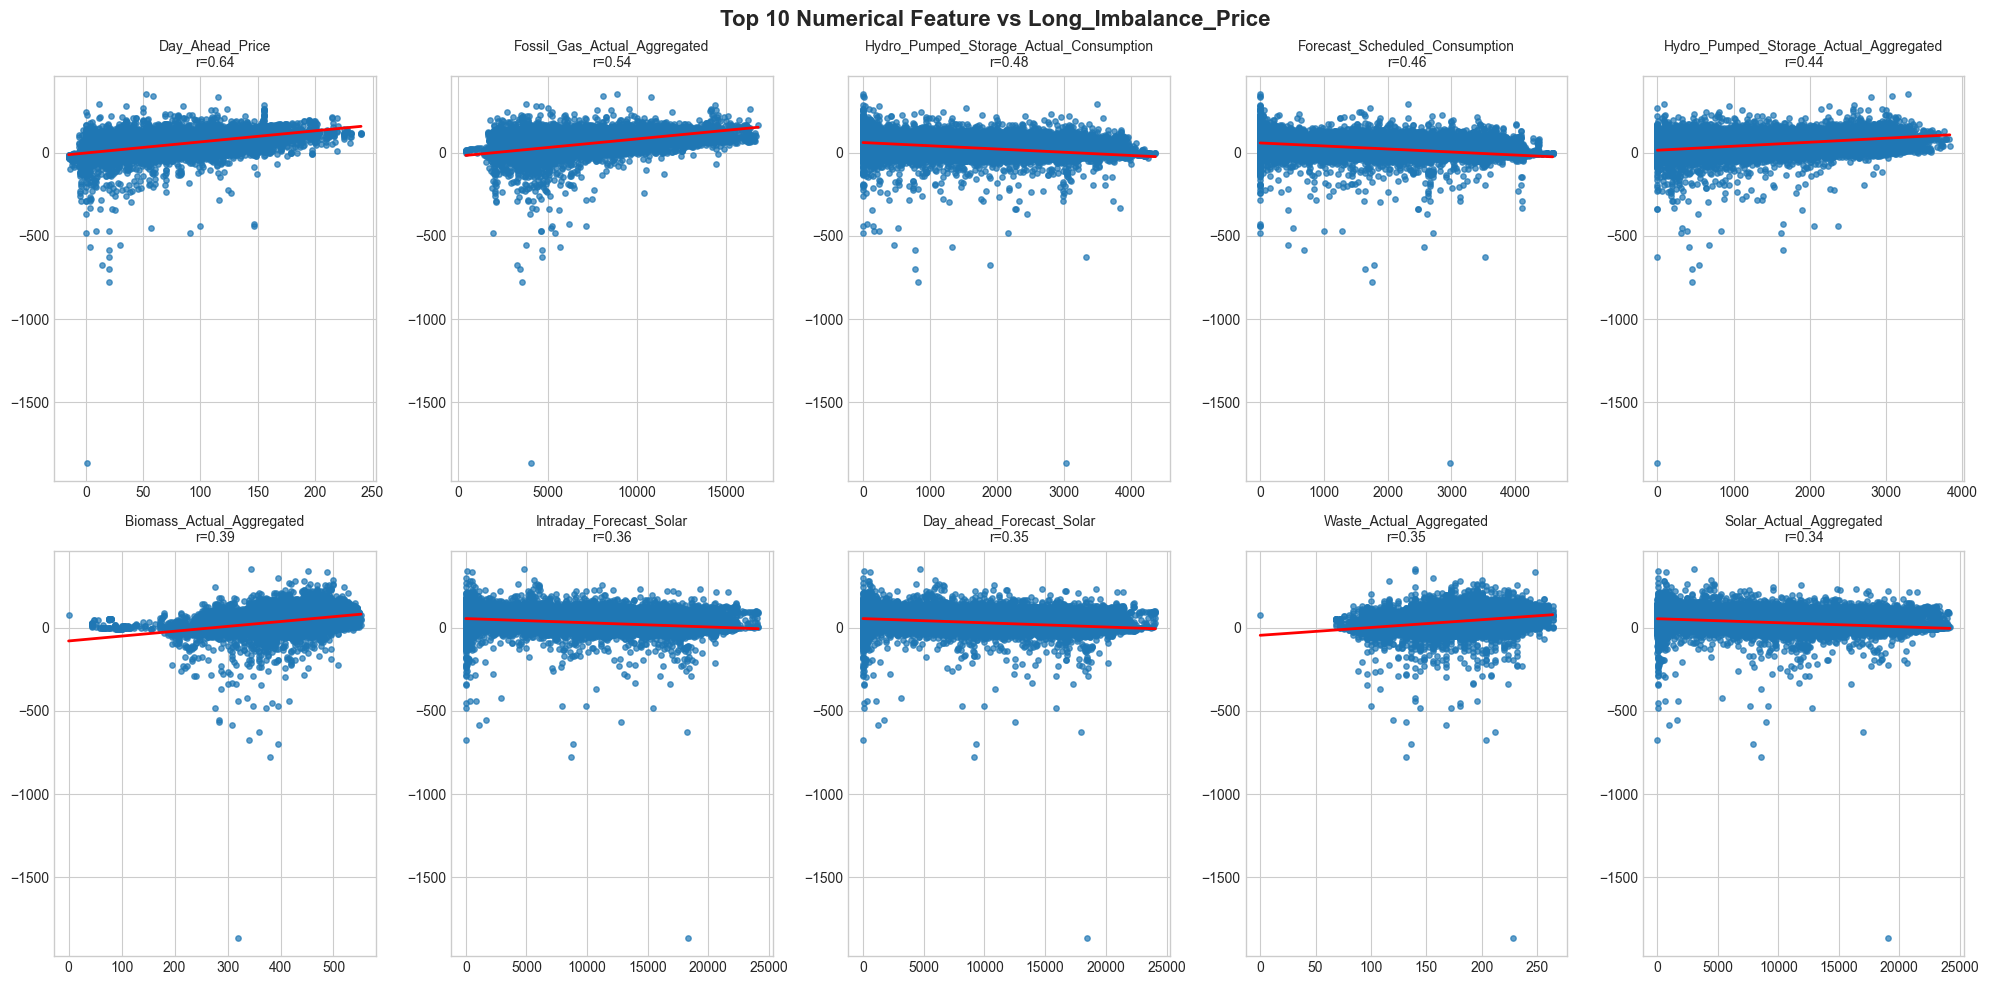

In [12]:
plot_top_correlated_features(data=data, target="Long_Imbalance_Price", nb_features=10)

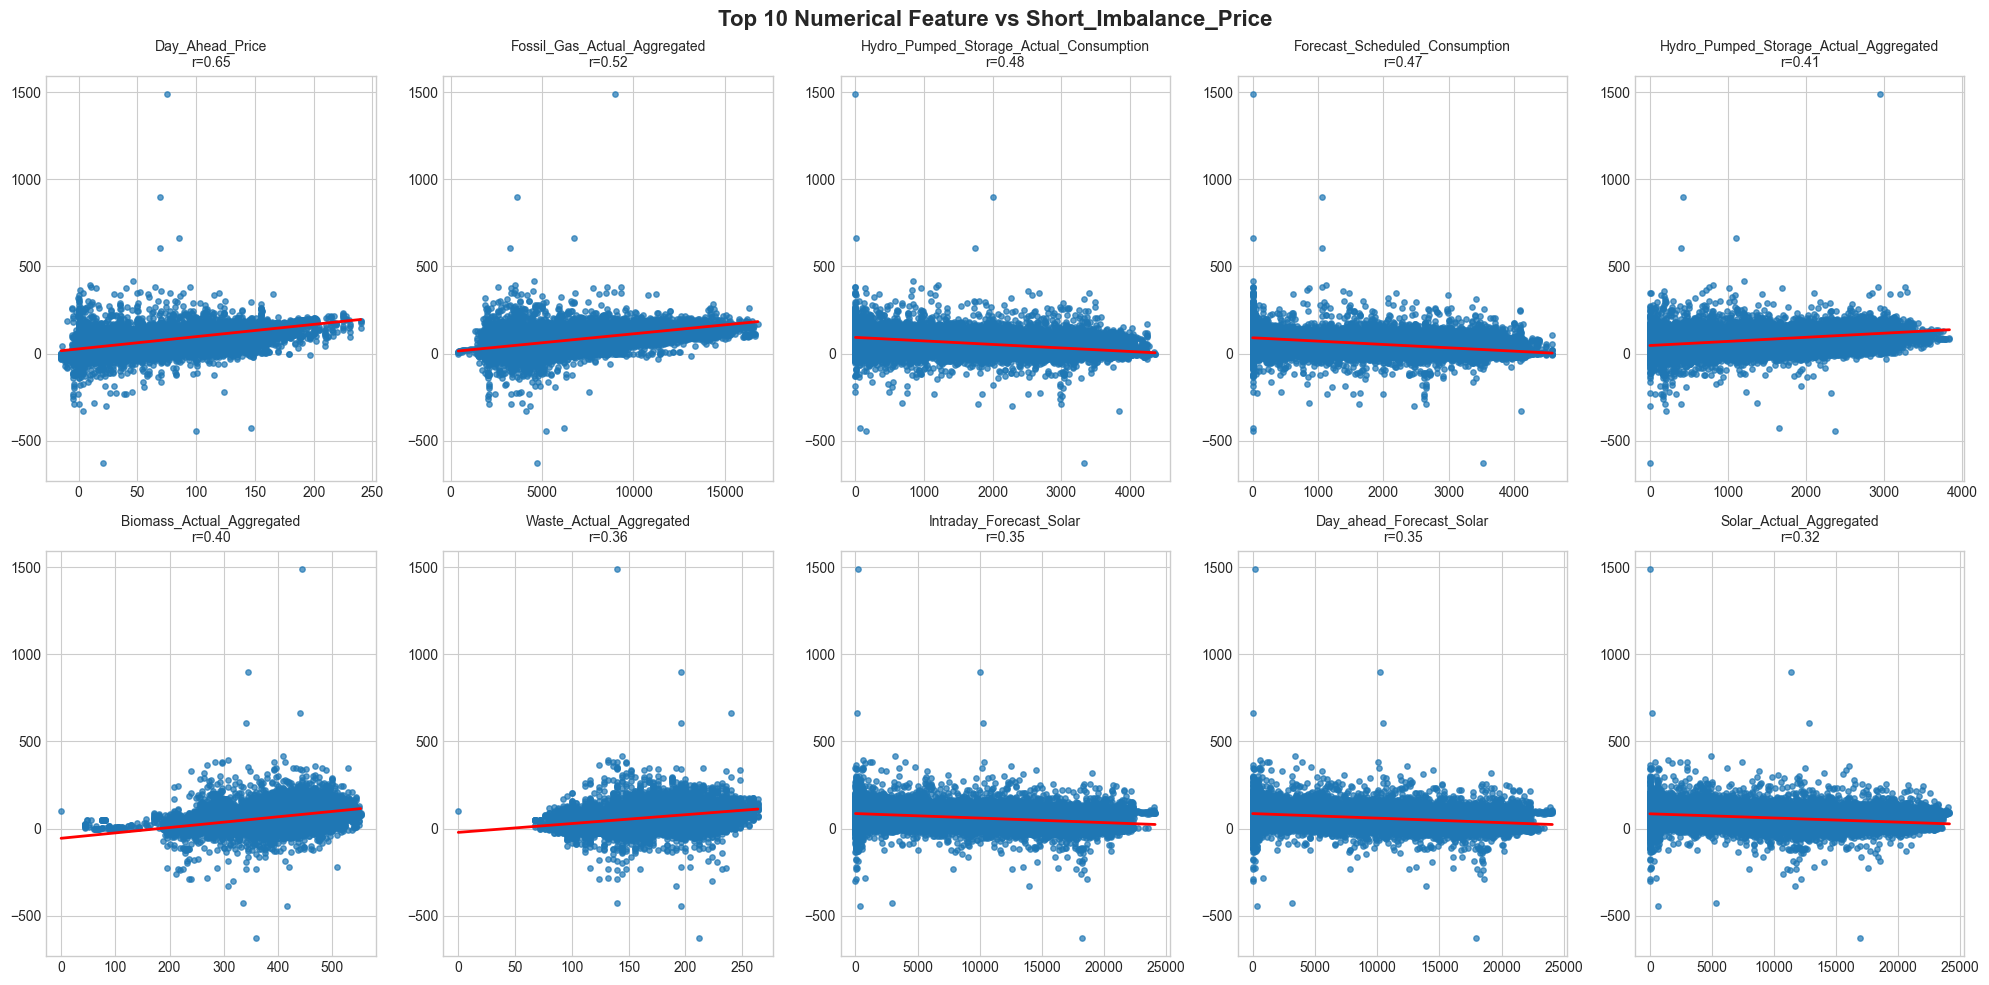

In [13]:
plot_top_correlated_features(data=data, target="Short_Imbalance_Price", nb_features=10)

Actual features will be lagged by ~4h (2h publication delay + 2h prediction horizon), making them unusable in their current form.
\
Forecasts are more relevant here as they are available ahead of time by design.

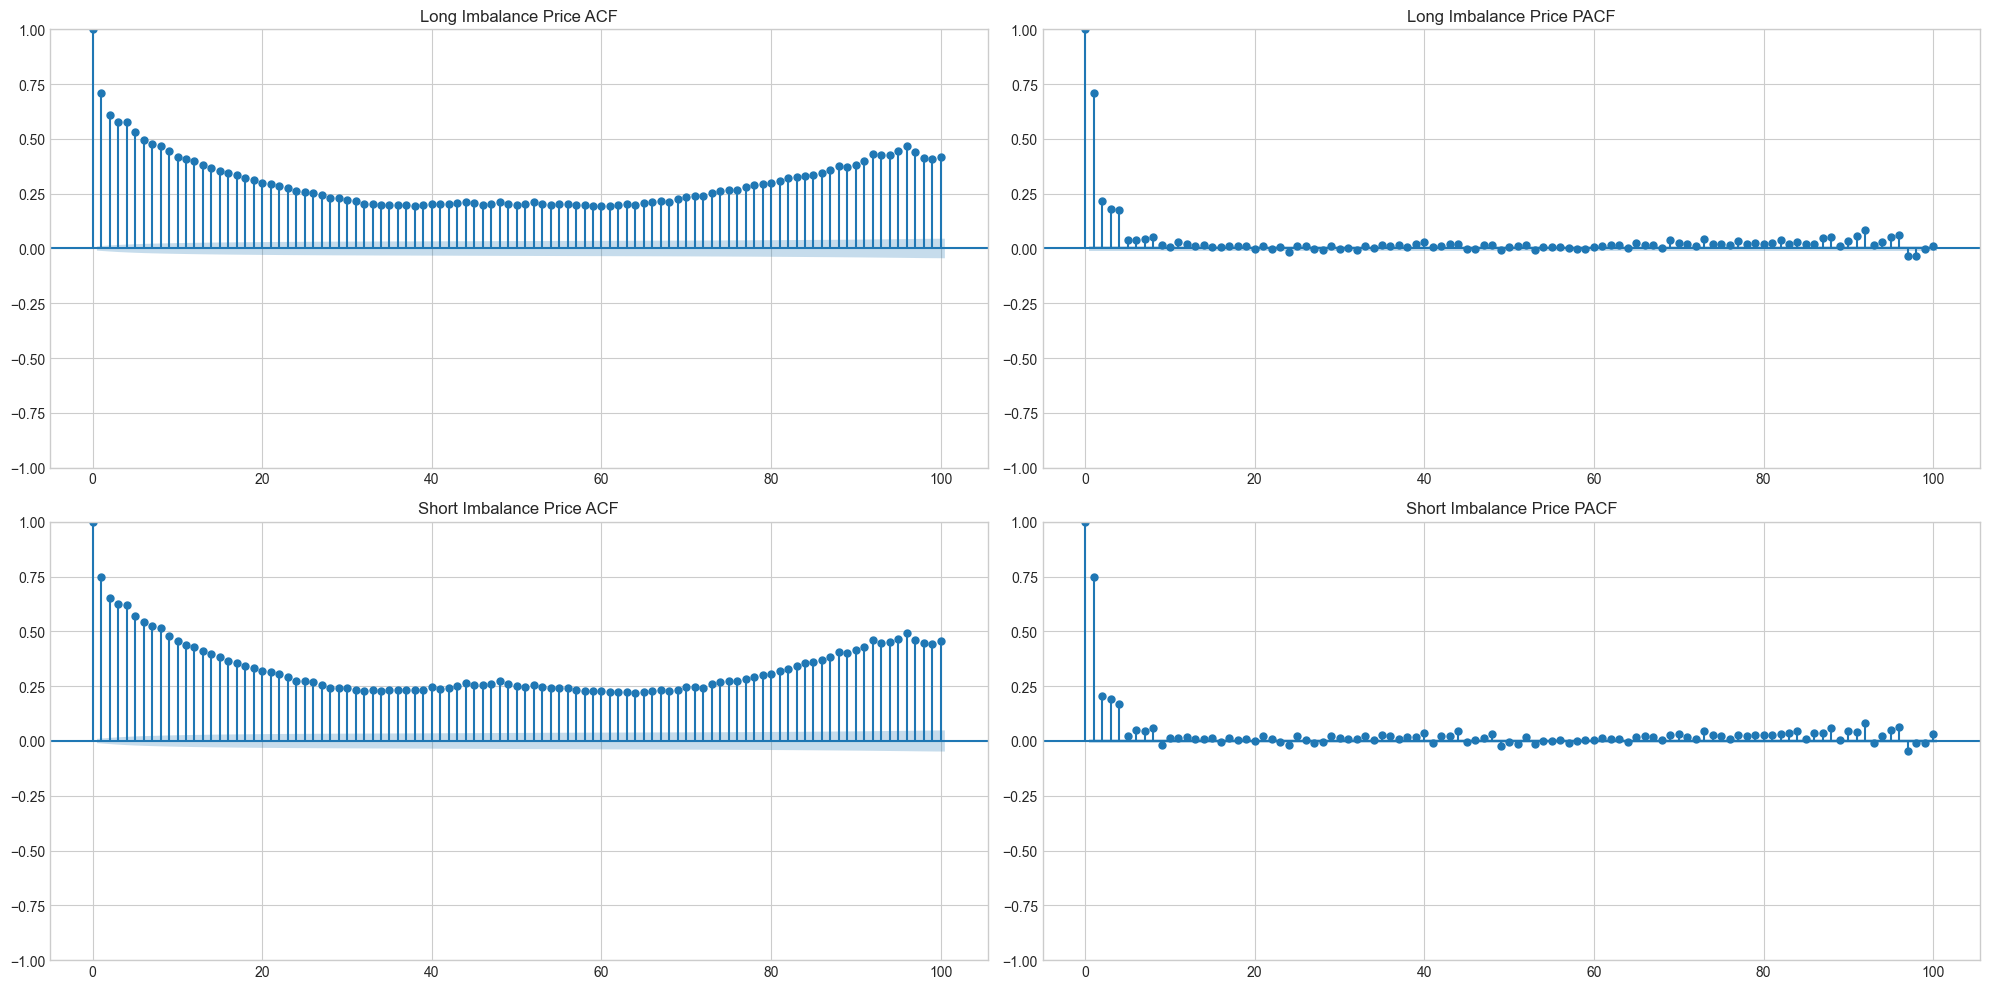

In [14]:
features = ["Long_Imbalance_Price", "Short_Imbalance_Price"]

plot_acf_pacf(data, features, 100)

* ACF measures how well a series is correlated with itself at different time lags, including the cumulative effect of all intermediate lags.
* The PACF measures the same thing but by isolating the direct relationship between the series and each lag, eliminating the influence of intermediate lags.


In our case looking at the PACF is more relevant, since the ACF takes into account the cumulative effect. Since we'll have a total lag of 4h, and our data is quaterly, that means we'll have a total lag of 16, thus only the lag 17 and onward are really interesting to look at here, and we see that the autocorrelation is very poor for both prices, so including them may add a little something but I'm not expecting it to have a major impact

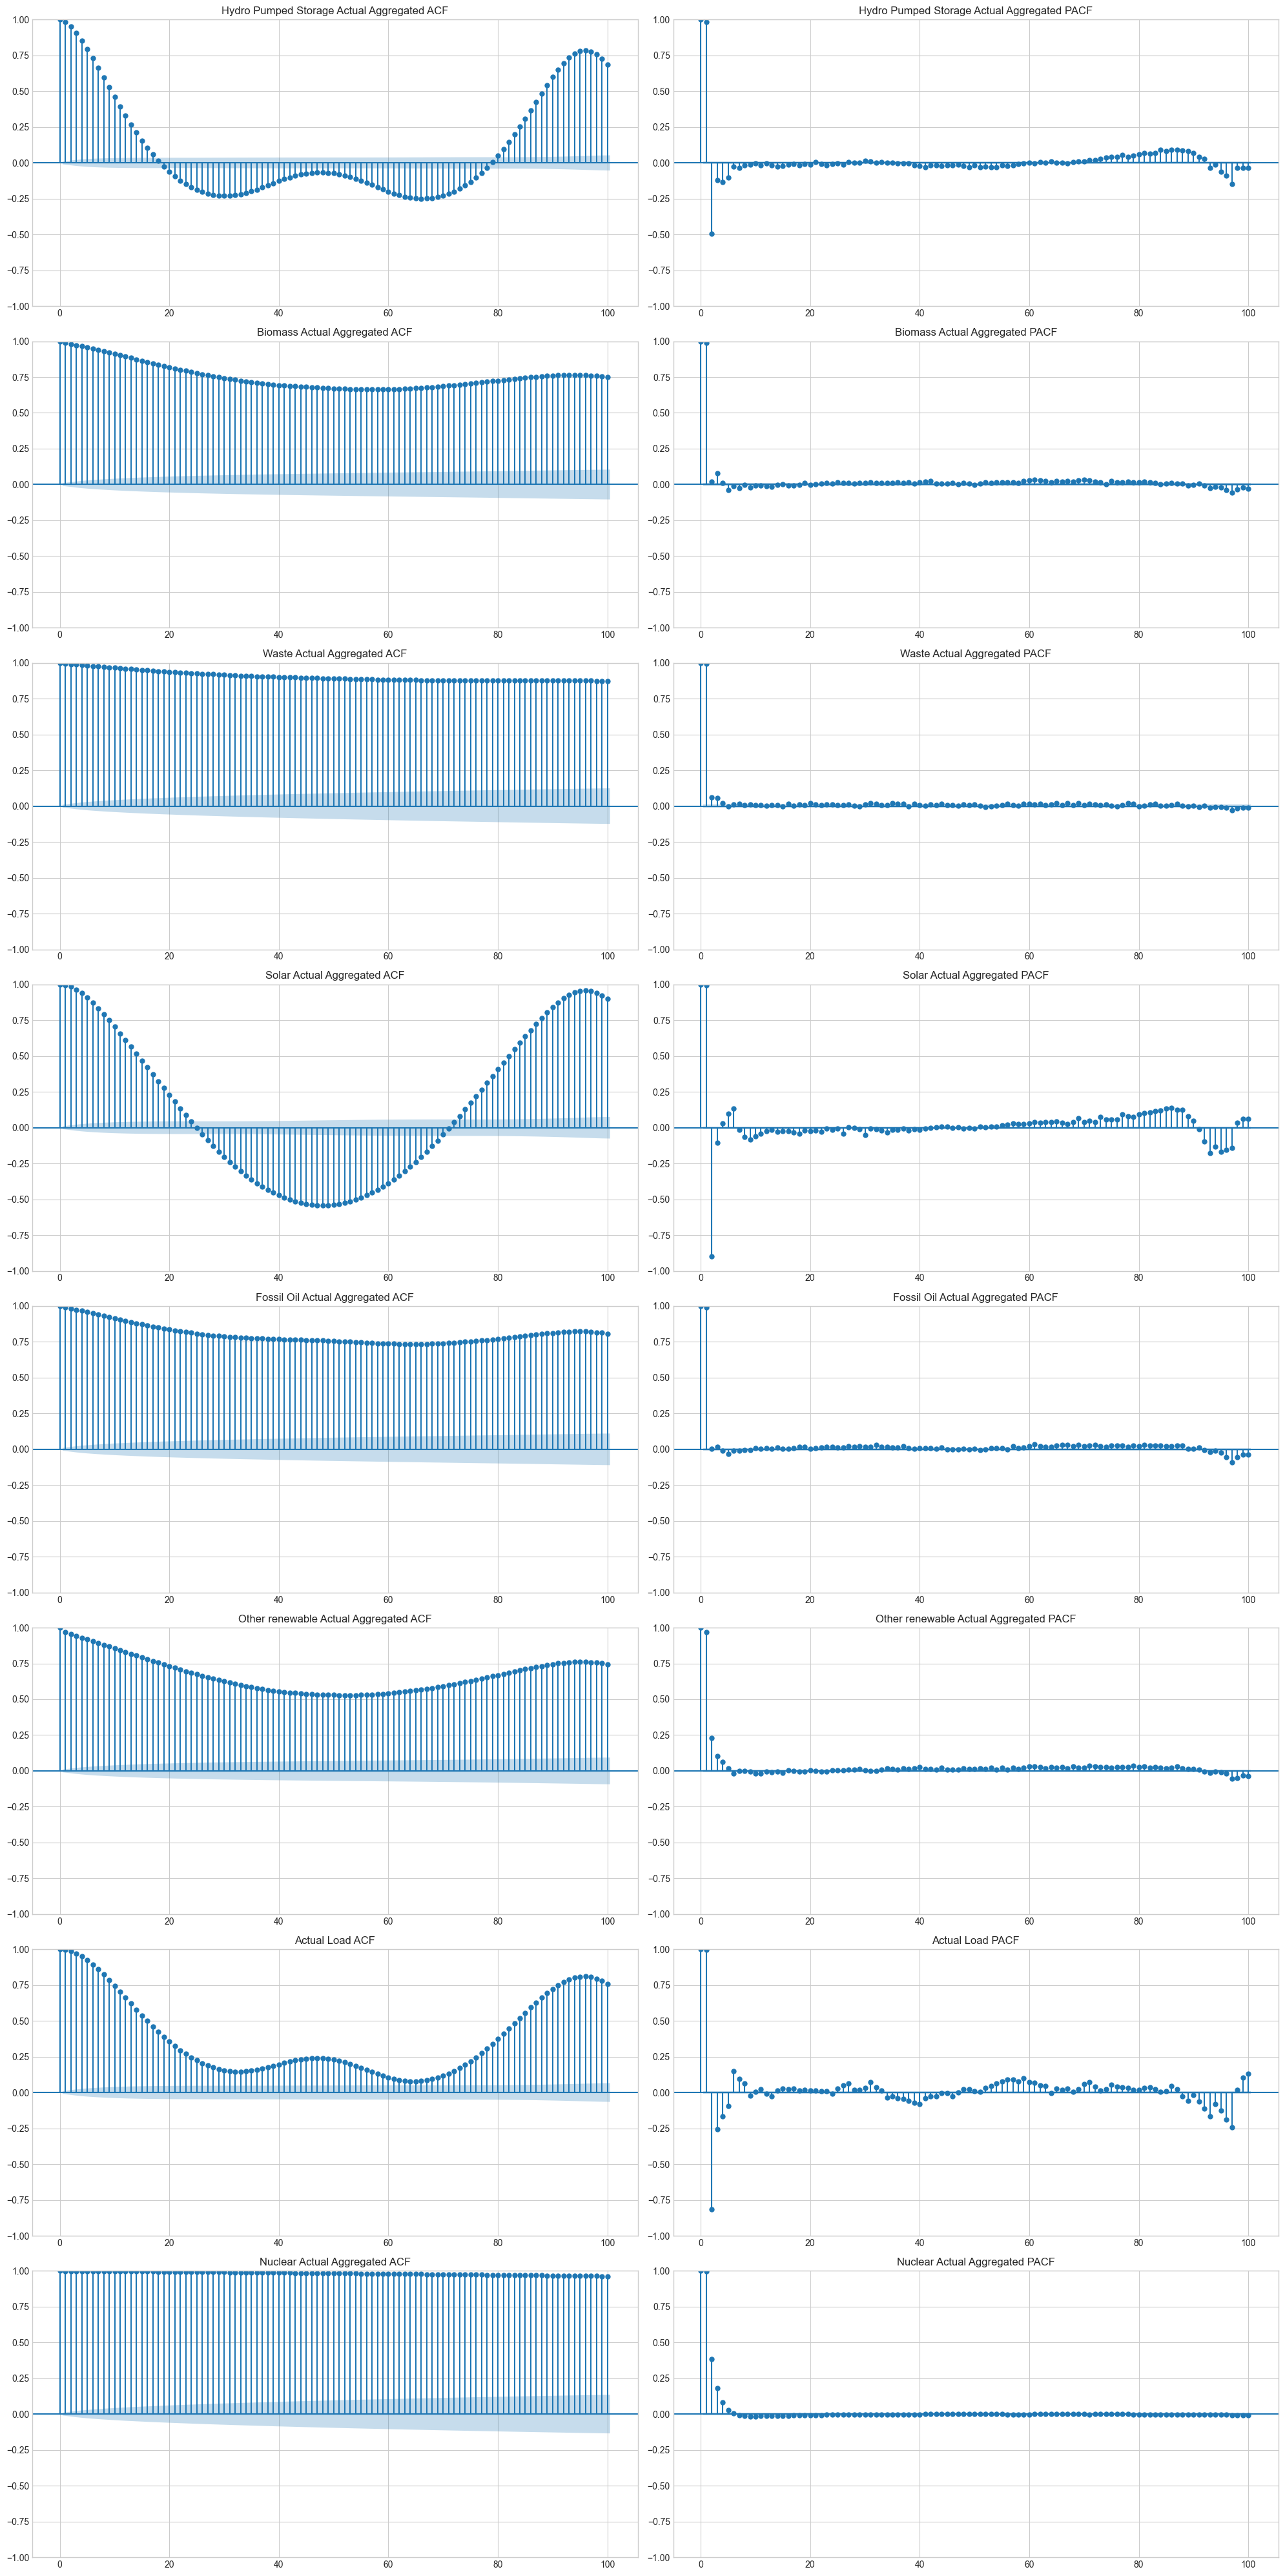

In [15]:
actuals_features = [col for col in data.columns if "actual" in col.lower()]
top_corr_actuals_features = data[actuals_features].corrwith(data["Long_Imbalance_Price"]).abs().sort_values(ascending=False)[2:10].index
plot_acf_pacf(data.dropna(subset=top_corr_actuals_features), top_corr_actuals_features, 100)

* Here, I am taking the top actuals correlated features and checking their autocorrelation. Since some of these variables won't be available due to the combined info and prediction lag (16 periods = 4h), I am looking to identify useful lags. The idea is simple: if a variable is highly correlated with the target, and that variable is also highly autocorrelated at lag 96, then lag 96 of that variable will also be correlated with the target, then it will be available at prediction time.

* We also see a boost in autocorrelation in the PACF starting around lag ~92, which makes sense as it represents approximately 23h of data, capturing the daily seasonality pattern.

In [16]:
def significant_lag(data: pd.DataFrame, feature: str, nlags: int = 100, top_lags: int = 10) -> list[int]:
    pacf_feature = pacf(data[feature].dropna(), nlags=nlags)
    significant_lags = np.argsort(np.abs(pacf_feature))[-top_lags:]
    significant_lags = significant_lags[significant_lags > 16]
    return significant_lags.tolist()

most_significant_lags = {}
for feat in top_corr_actuals_features:
    most_significant_lags[feat] = significant_lag(data=data, feature=feat)

print(*(f"{feature}: {lags}" for feature, lags in most_significant_lags.items()), sep="\n")

Hydro_Pumped_Storage_Actual_Aggregated: [84, 86, 87, 97]
Biomass_Actual_Aggregated: [100, 61, 70, 98, 96, 97]
Waste_Actual_Aggregated: [78, 69, 65, 35, 97]
Solar_Actual_Aggregated: [85, 86, 97, 96, 95, 93]
Fossil_Oil_Actual_Aggregated: [72, 61, 100, 99, 96, 98, 97]
Other_renewable_Actual_Aggregated: [71, 100, 79, 98, 97]
Actual_Load: [100, 93, 96, 97]
Nuclear_Actual_Aggregated: []


We retrieve the best lags after lag 16,

In [17]:
lagged_features = []
for feat, lags in most_significant_lags.items():
    if not lags:
        continue
    shifted_df = data[feat].shift(periods=lags, suffix="Lag")
    lagged_features_name = shifted_df.columns.to_list()
    data[ lagged_features_name] = shifted_df
    lagged_features +=  lagged_features_name

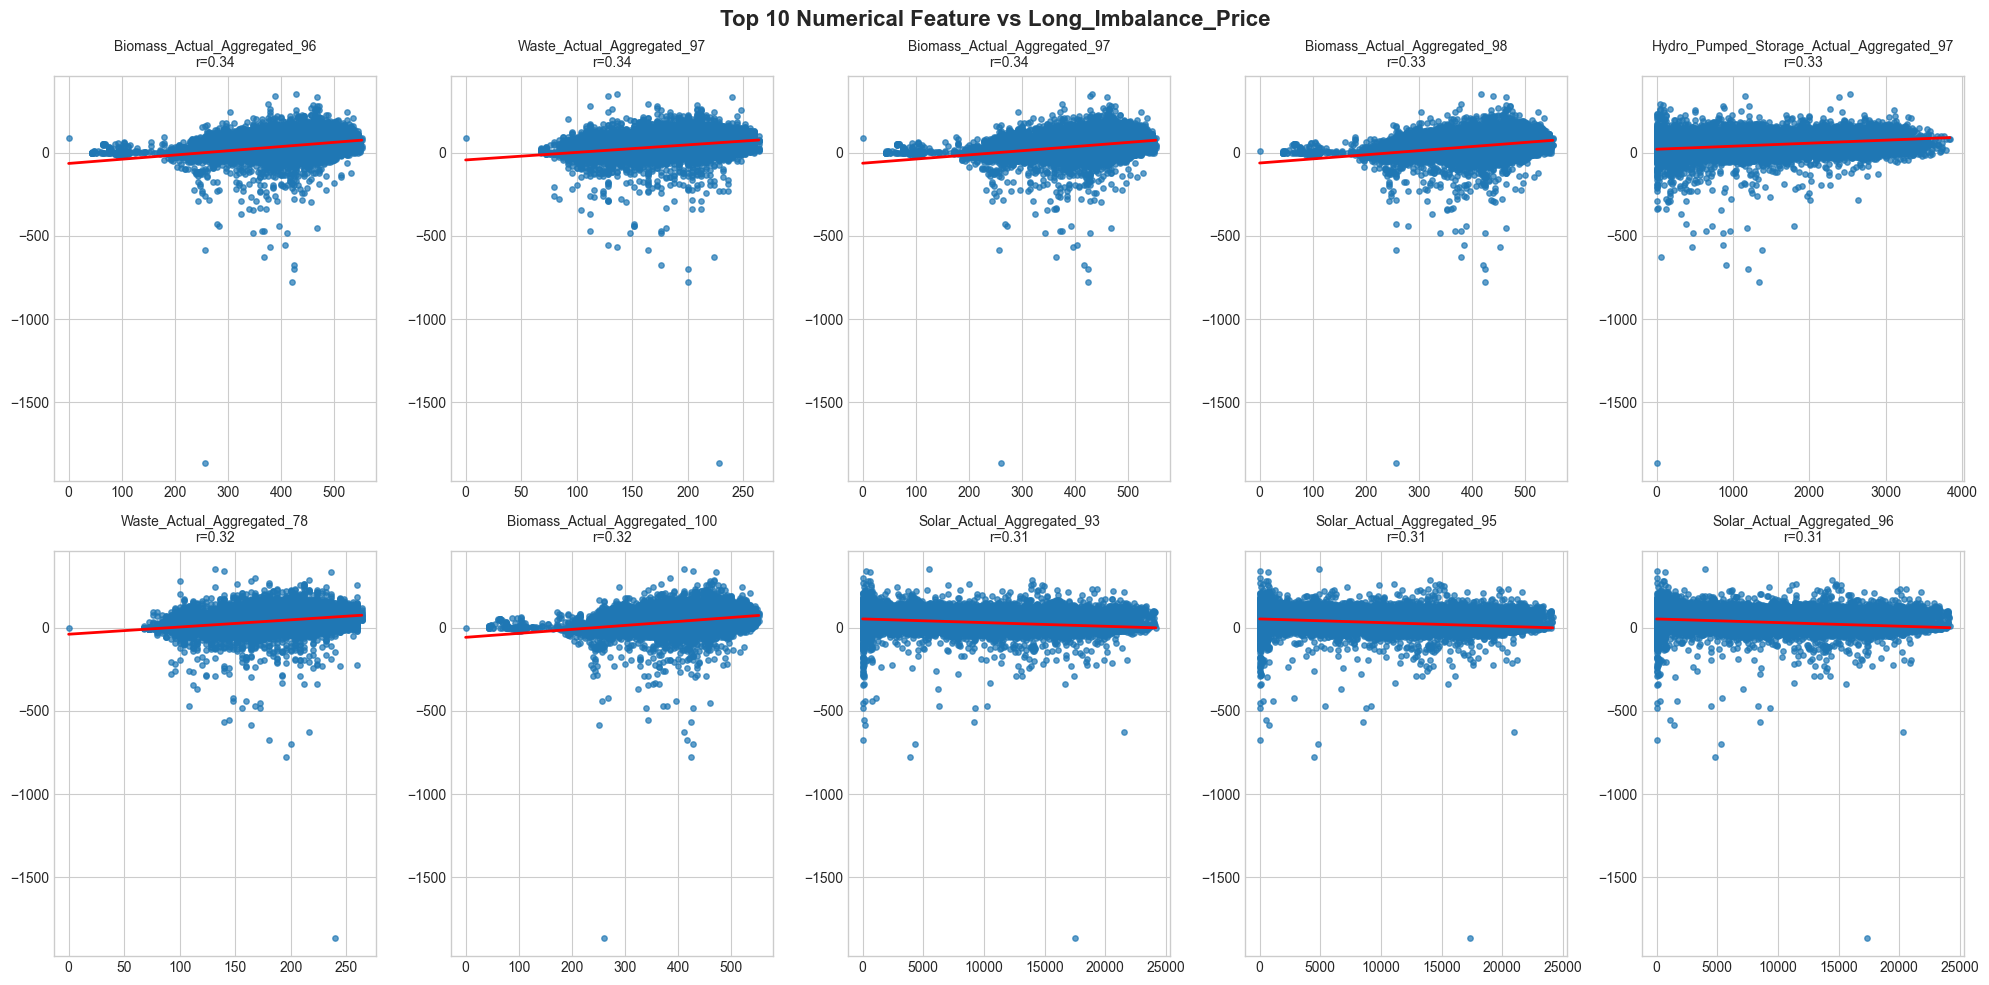

In [18]:
plot_top_correlated_features(data, target="Long_Imbalance_Price", nb_features=10, subset=lagged_features)

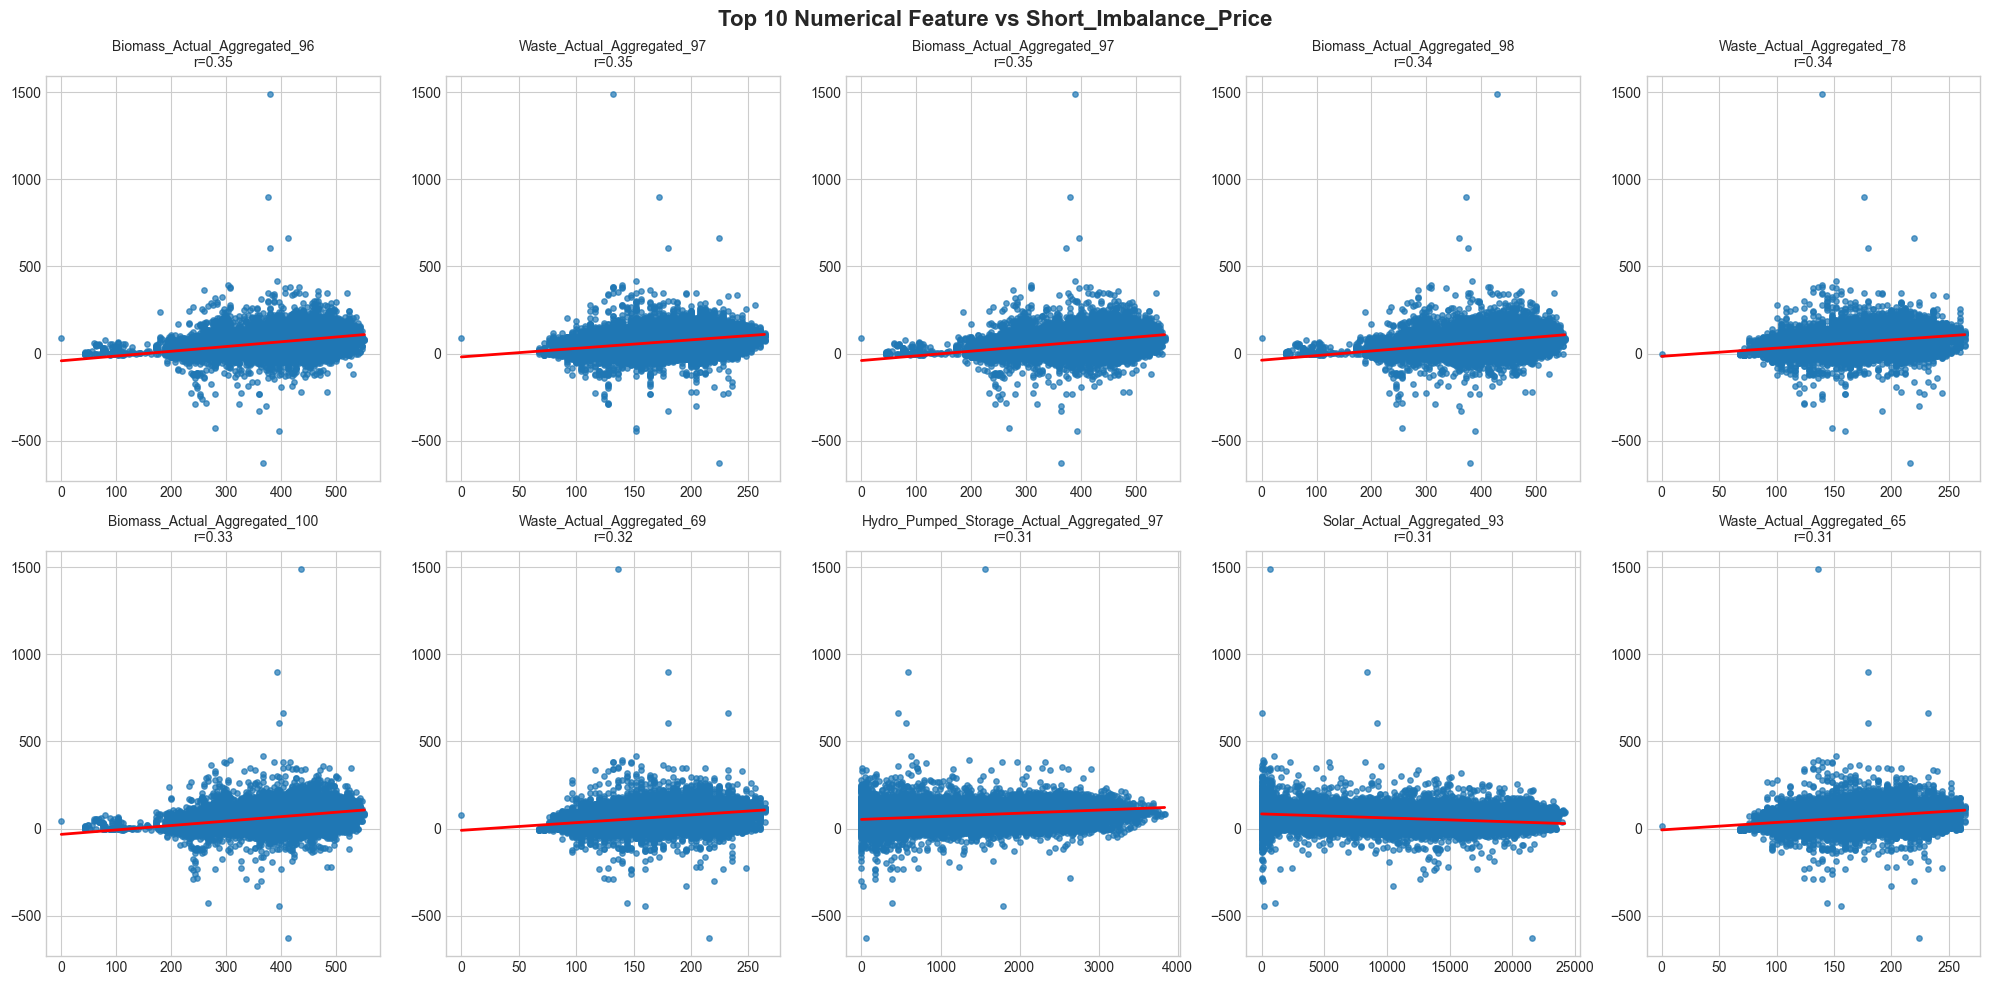

In [19]:
plot_top_correlated_features(data, target="Short_Imbalance_Price", nb_features=10, subset=lagged_features)

Despite the large lags, we still see a decent correlation of around 32% with the target, so these variables will be included as lagged features during the feature engineering step.

## Feature Engineering

In [20]:
data = load_parquet(energy_data)

* **Deltas Between Actual and Forecasts**

These features are relevant because imbalance prices are driven by the gap between actual and forecasted production/consumption. The most relevant are renewables (Wind/Solar) since these energy types are highly volatile and depend on meteorological conditions that cannot be controlled. We also compute the delta for total aggregated production, i.e. the difference between total forecasted and actual production. These variables will also have to be lagged

* **Remainder Volume**

Computed as: forecasted_consumption - (forecasted_production + scheduled_imports - scheduled_exports). If positive, the system is more likely to be in deficit; if negative, in surplus


* **Available Intraday Flow**

Computed as: NTC - scheduled_flow (imports or exports). NTC (Net Transfer Capacity) represents the maximum transfer capacity between two countries, while scheduled flow represents the already allocated capacity in the day-ahead market. This variable indicates how much additional import/export capacity remains available. If the NTC is nearly maxed out by scheduled flows, the country will have limited ability to balance itself through cross-border exchanges and will have to rely solely on its own production.

* **DateTime Features**

As observed in the EDA, the bimodality of Long/Short Imbalance prices is likely driven by the time of day, day of the week, and season, as consumption and production patterns vary significantly across these periods. To capture these cyclical patterns, we will encode temporal features using sin/cos transformations, which preserve the circular nature of time (e.g. hour 23 is close to hour 0).

### New features

In [21]:
actual_cols = [col for col in data.columns if "actual" in col.lower()]
data[["Energy_storage_Actual_Aggregated", "Energy_storage_Actual_Consumption"]] = data[["Energy_storage_Actual_Aggregated", "Energy_storage_Actual_Consumption"]].fillna(0)

We fill Energy Storage Actual with zeros, as we've seen in the missing values analysis that the quantile Q1 is equal to 0, and the mean is equal to 0.84

In [22]:
consumption_cols = ["Energy_storage_Actual_Consumption", "Hydro_Pumped_Storage_Actual_Consumption"]
production_cols = list(set(actual_cols) - set(consumption_cols) - {"Actual_Load"})

data["Total_Production_Actual"] = data[production_cols].sum(axis=1) - data[consumption_cols].sum(axis=1)

Consumption here refers to the energy consumed by hydraulic pumping stations to pump water uphill for storage. Since this represents energy consumed rather than produced, it must be subtracted from the total production figure to obtain the net actual production.

In [23]:
#Total Production Delta
data["Total_Production_Delta_Actual"] = data["Forecast_Scheduled_Aggregated"] - data["Forecast_Scheduled_Consumption"] - data["Total_Production_Actual"]

#Wind Production Delta
data["Wind_Production_Day_Ahead_Delta_Actual"] = data["Day_ahead_Forecast_Wind_Onshore"] - data["Wind_Onshore_Actual_Aggregated"]

data["Wind_Production_Intraday_Delta_Actual"] = data["Intraday_Forecast_Wind_Onshore"] - data["Wind_Onshore_Actual_Aggregated"]

#Solar Production Delta
data["Solar_Production_Day_Ahead_Delta_Actual"] = data["Day_ahead_Forecast_Solar"] - data["Solar_Actual_Aggregated"]

data["Solar_Production_Intraday_Delta_Actual"] = data["Intraday_Forecast_Solar"] - data["Solar_Actual_Aggregated"]

#Consumption
data["Load_Delta_Actual"] = data["Forecasted_Load"] - data["Actual_Load"]

#Scheduled imports
data["Scheduled_Imports"] = data["scheduled_exchange_PT>ES"] + data["scheduled_exchange_FR>ES"]

#Scheduled exports
data["Scheduled_Exports"] = data["scheduled_exchange_ES>FR"] + data["scheduled_exchange_ES>PT"]

#Remainder Volume
data["Scheduled_Remainder_Volume"] = data["Forecasted_Load"] - (data["Forecast_Scheduled_Aggregated"] - data["Forecast_Scheduled_Consumption"] + data["Scheduled_Imports"] - data["Scheduled_Exports"])

#Available Intraday Flow
data["Intraday_NTC_Available_PT>ES"] = data["ntc_PT>ES"] - data["scheduled_exchange_PT>ES"]
data["Intraday_NTC_Available_ES>PT"] = data["ntc_ES>PT"] - data["scheduled_exchange_ES>PT"]
data["Intraday_NTC_Available_ES>FR"] = data["ntc_ES>FR"] - data["scheduled_exchange_ES>FR"]
data["Intraday_NTC_Available_FR>ES"] = data["ntc_FR>ES"] - data["scheduled_exchange_FR>ES"]

In [24]:
new_features = ["Total_Production_Delta_Actual",
                "Wind_Production_Day_Ahead_Delta_Actual",
                "Wind_Production_Intraday_Delta_Actual",
                "Solar_Production_Day_Ahead_Delta_Actual",
                "Solar_Production_Intraday_Delta_Actual",
                "Load_Delta_Actual",
                "Scheduled_Imports",
                "Scheduled_Exports",
                "Scheduled_Remainder_Volume",
                "Intraday_NTC_Available_PT>ES",
                "Intraday_NTC_Available_ES>PT",
                "Intraday_NTC_Available_ES>FR",
                "Intraday_NTC_Available_FR>ES"]

new_features_actuals = [col for col in new_features if "actual" in col.lower()]

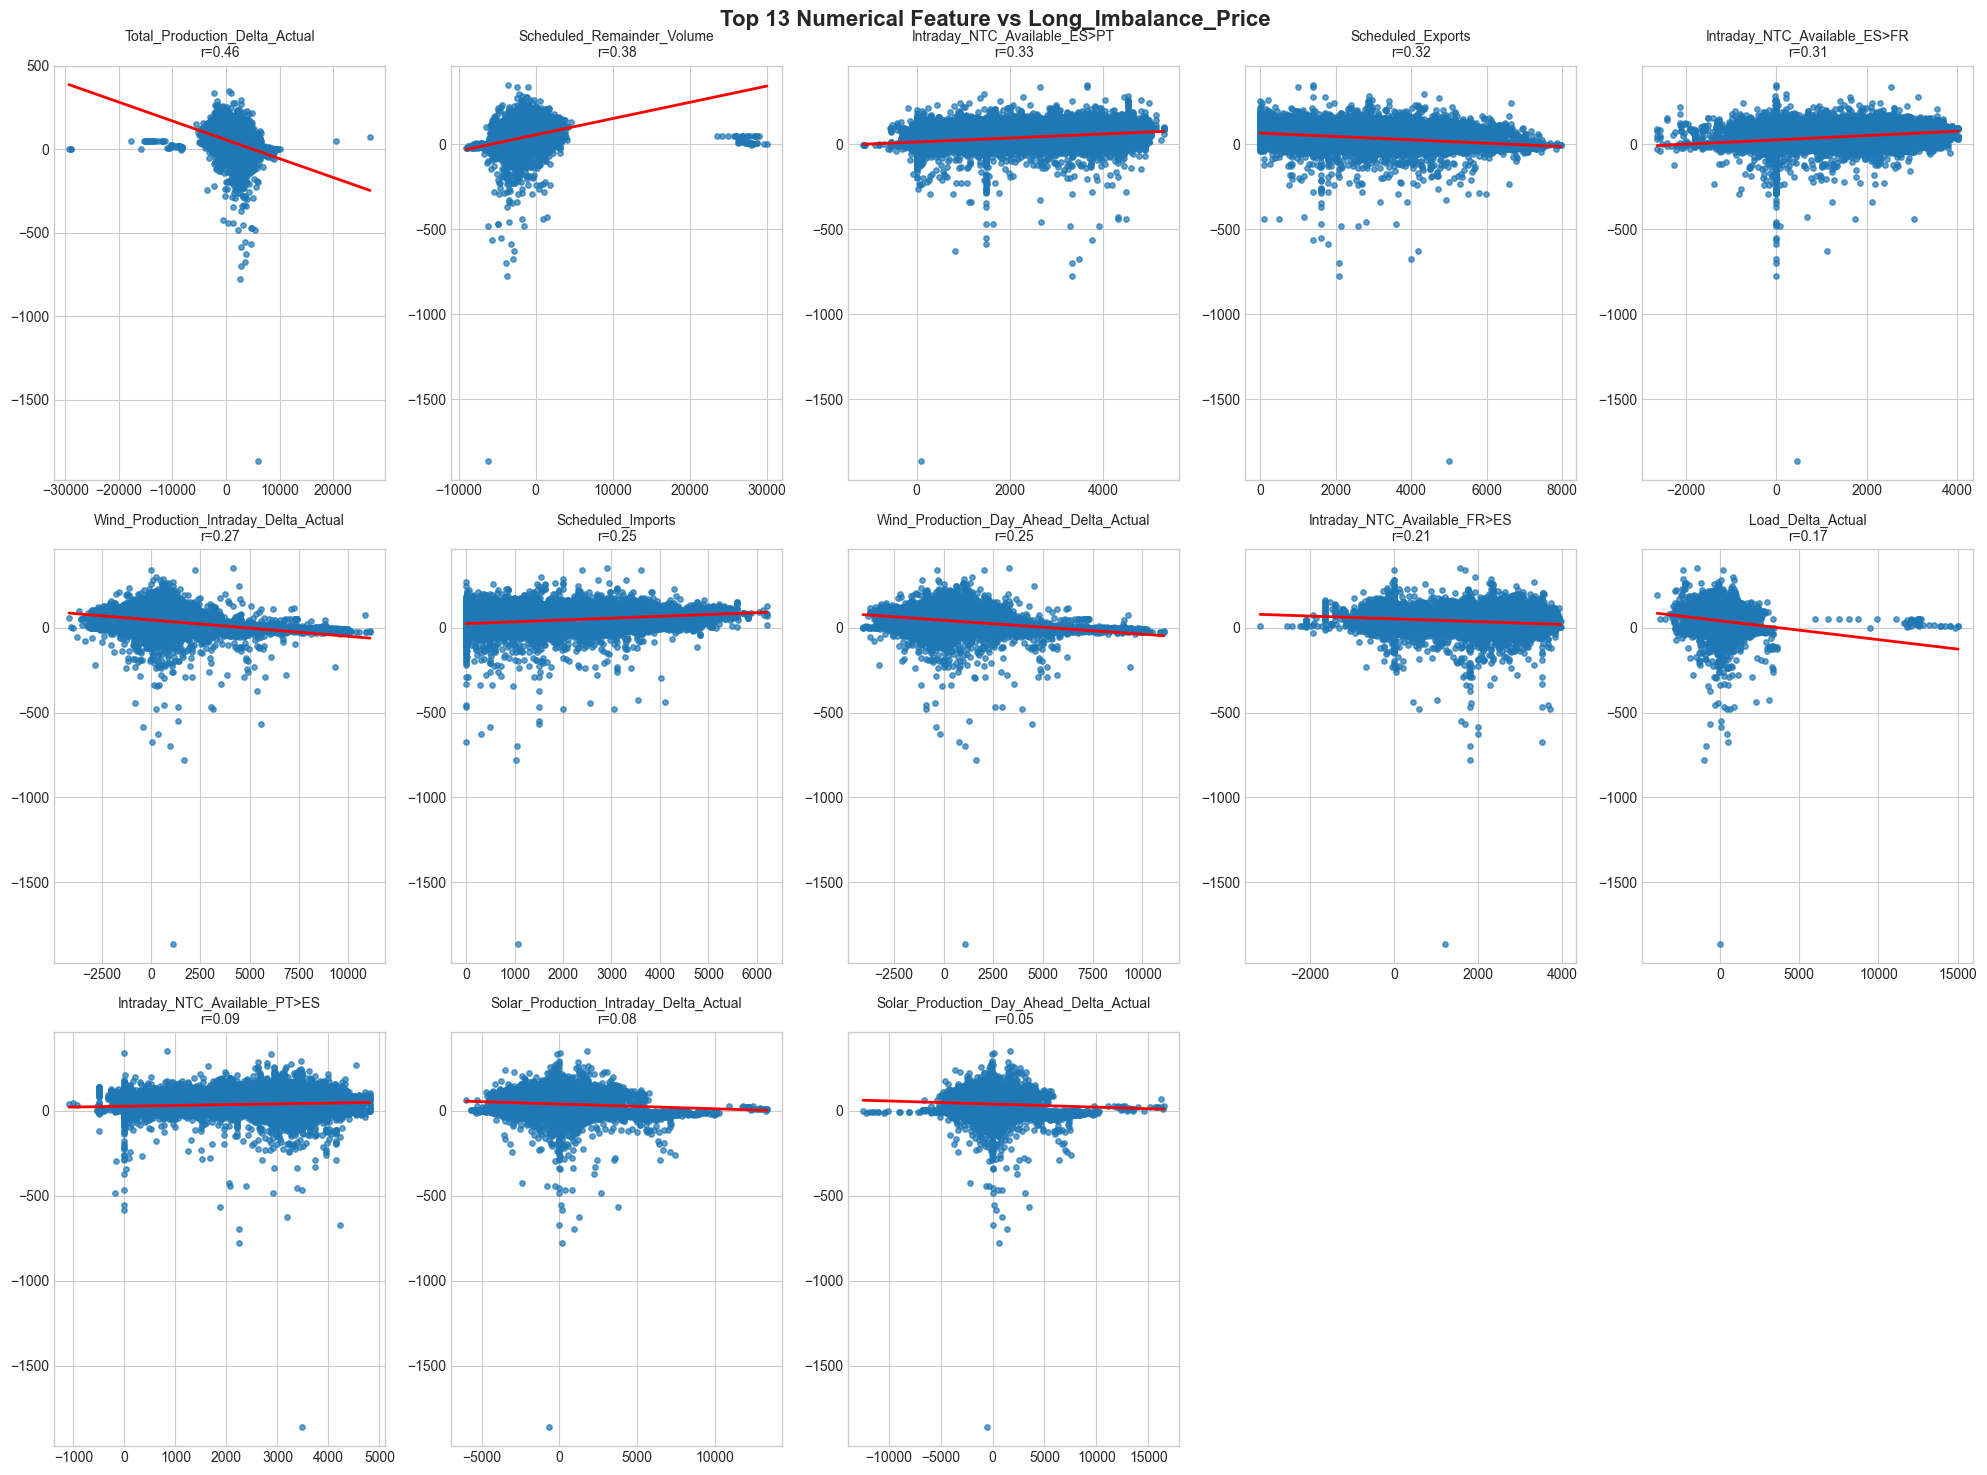

In [25]:
plot_top_correlated_features(data, target="Long_Imbalance_Price", nb_features=13, subset=new_features)

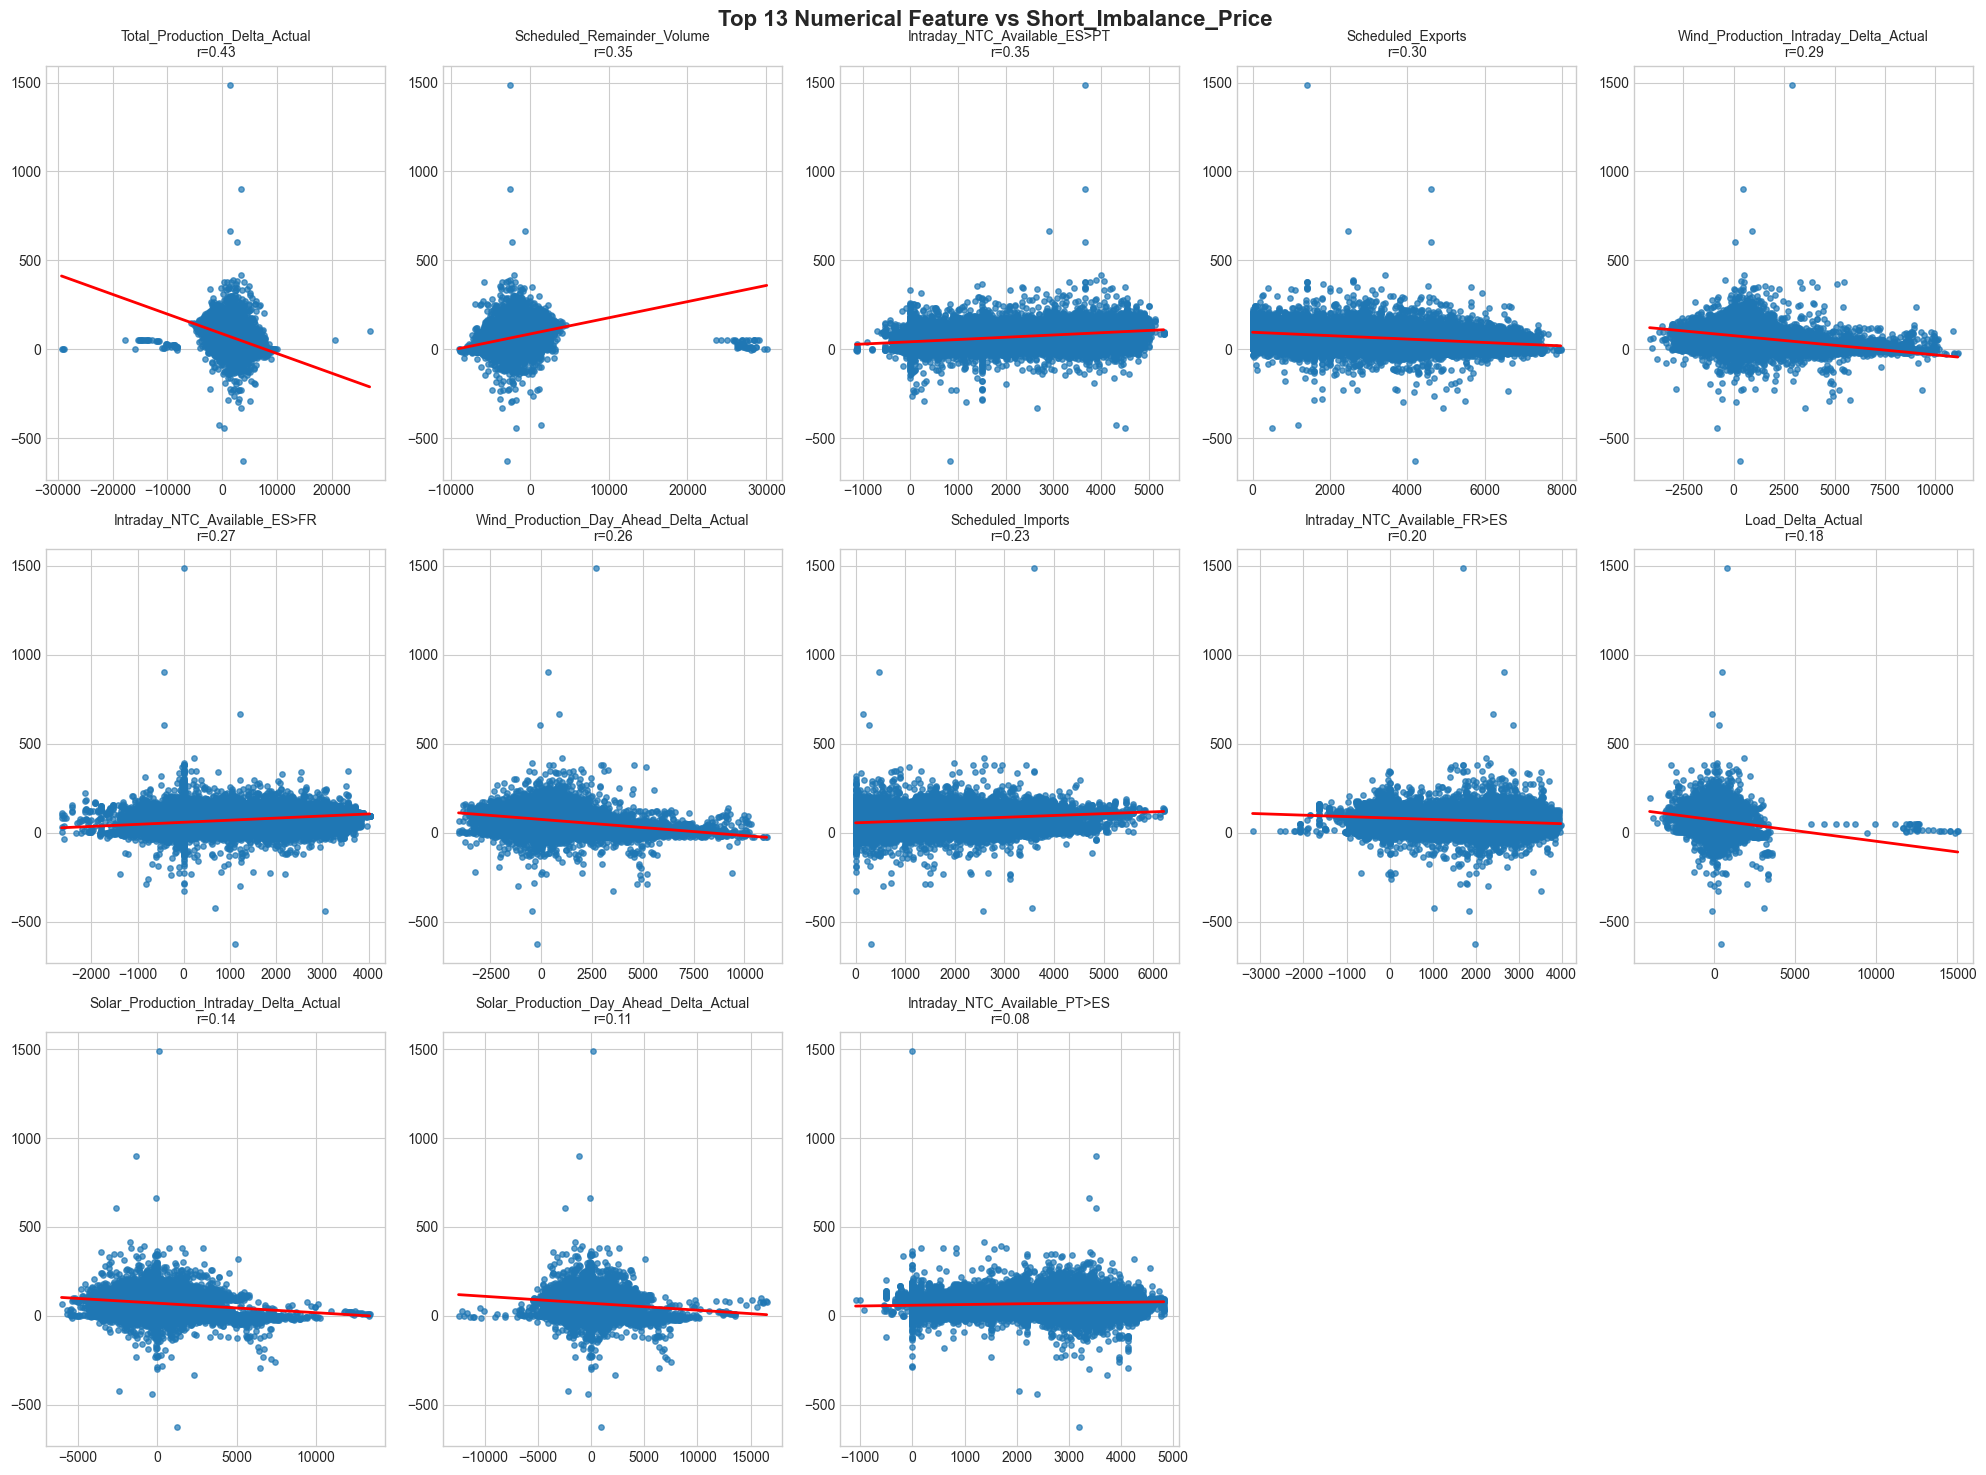

In [26]:
plot_top_correlated_features(data, target="Short_Imbalance_Price", nb_features=13, subset=new_features)

Looking at the scatter plots, none of the delta features show a strong linear relationship with the target.
\
However, we expect the model to capture non-linear relationships that are not visible here. The only exception is one variable with a correlation of 0.43, although the scatter plot reveals a blob-like pattern with no clear linear trend.
\
As for remainder flow and scheduled exchange features, some show a slight linear relationship with the target.\
It is worth noting that delta features will need to be lagged since they are computed from actual values which are not available at prediction time.

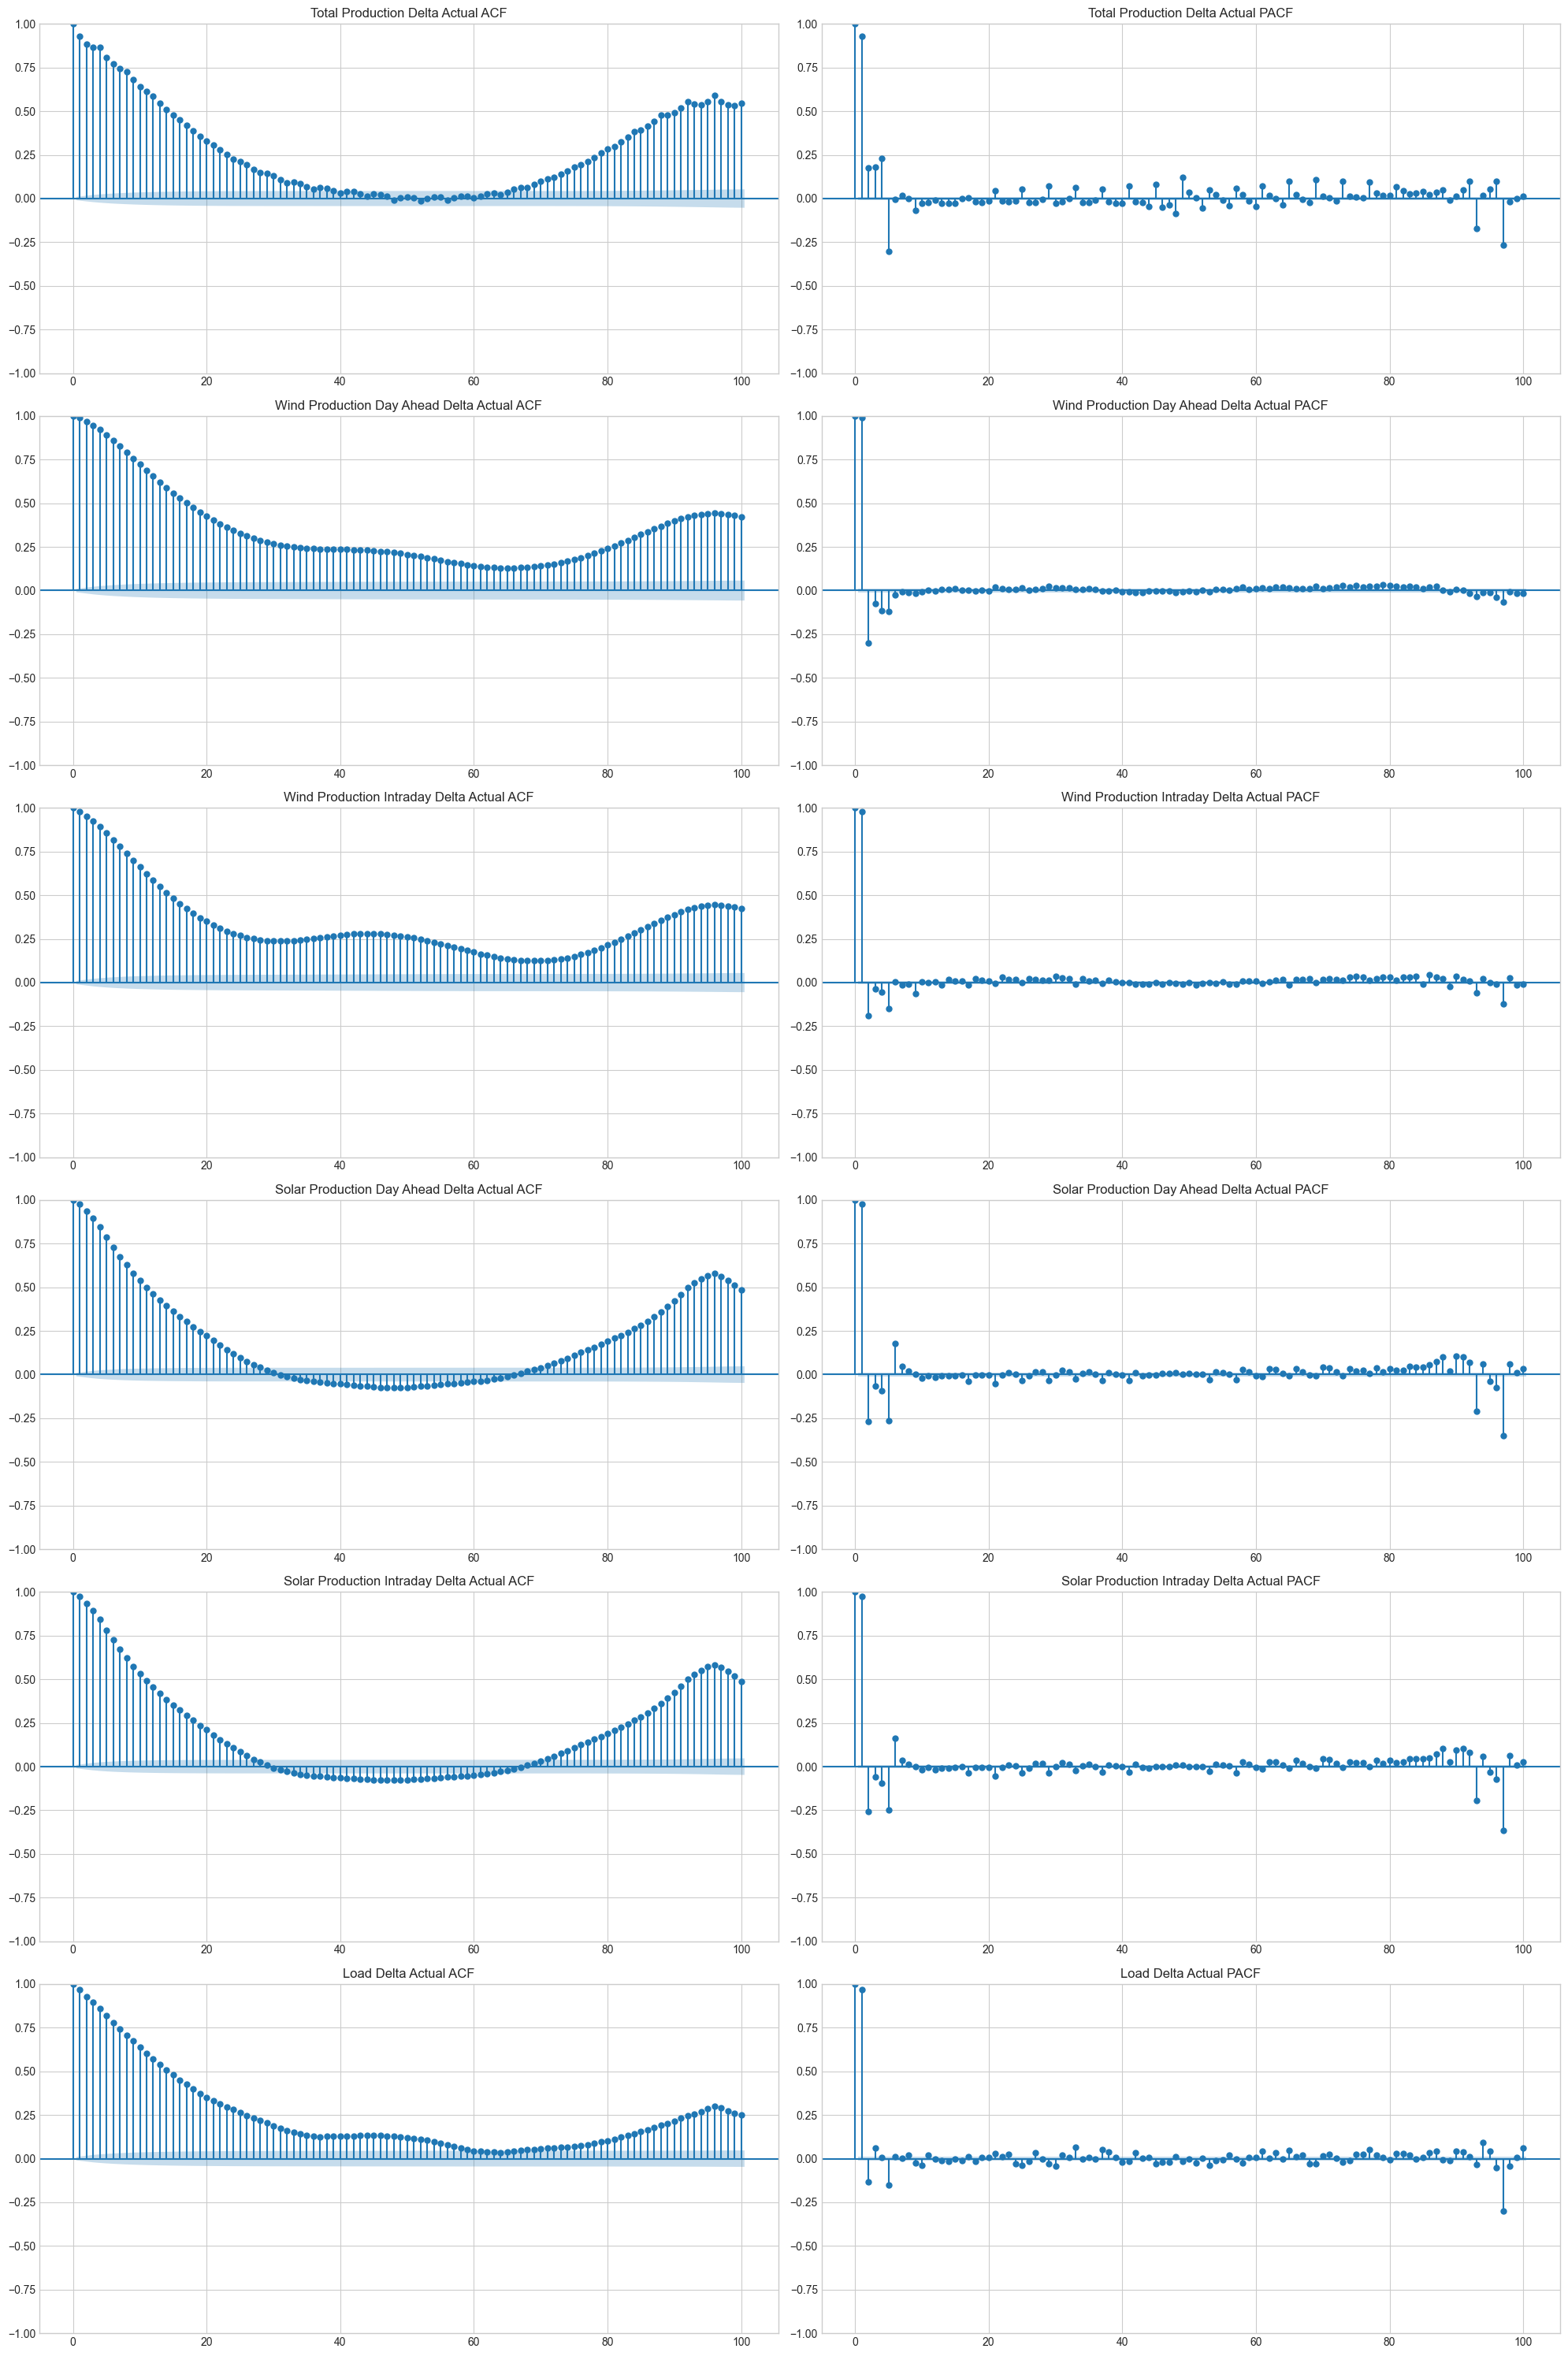

In [27]:
plot_acf_pacf(data.dropna(subset=new_features_actuals), new_features_actuals, 100)

In [28]:
most_significant_lags = {}
for feat in new_features_actuals:
    most_significant_lags[feat] = significant_lag(data=data, feature=feat)

print(*(f"{feature}: {lags}" for feature, lags in most_significant_lags.items()), sep="\n")

lagged_features = []
for feat, lags in most_significant_lags.items():
    if not lags:
        continue
    shifted_df = data[feat].shift(periods=lags, suffix="Lag")
    lagged_features_name = shifted_df.columns.to_list()
    data[ lagged_features_name] = shifted_df
    lagged_features +=  lagged_features_name

Total_Production_Delta_Actual: [69, 49, 93, 97]
Wind_Production_Day_Ahead_Delta_Actual: [79, 93, 96, 97]
Wind_Production_Intraday_Delta_Actual: [86, 93, 97]
Solar_Production_Day_Ahead_Delta_Actual: [88, 90, 93, 97]
Solar_Production_Intraday_Delta_Actual: [88, 91, 93, 97]
Load_Delta_Actual: [37, 100, 33, 94, 97]


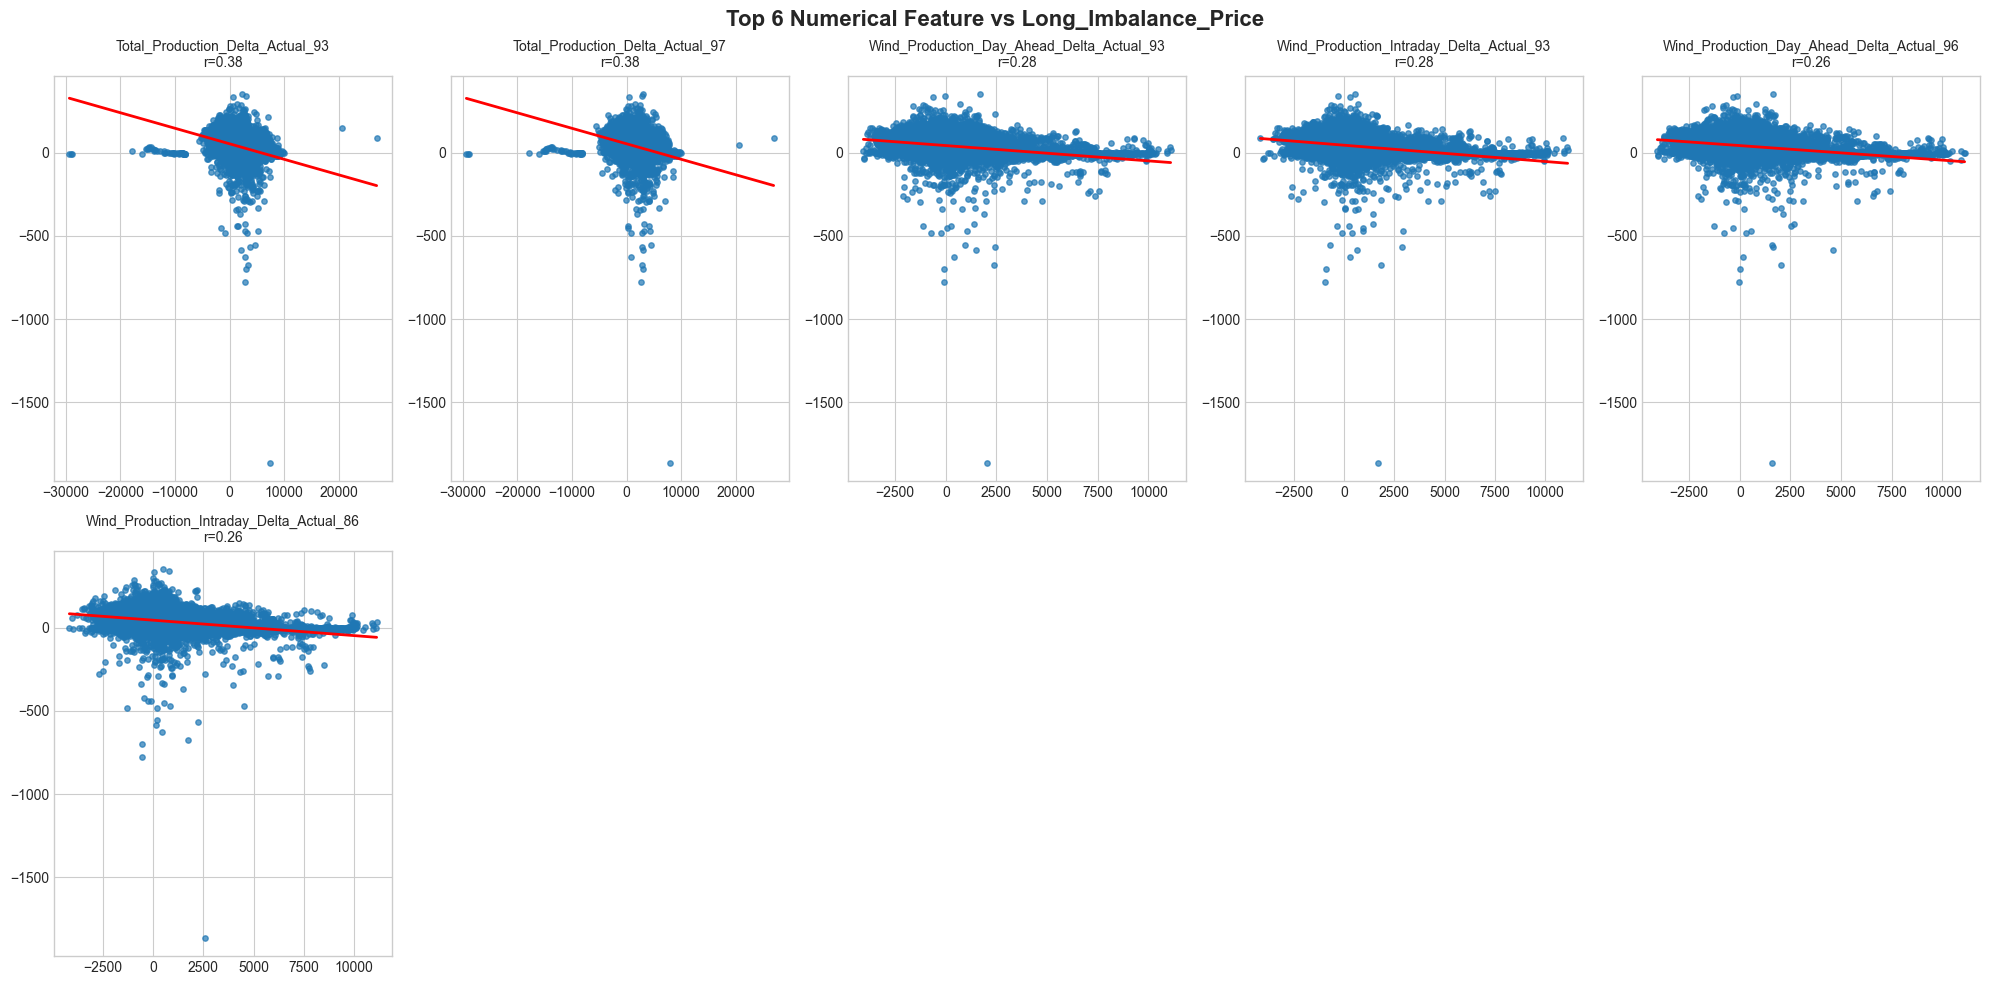

In [29]:
plot_top_correlated_features(data, target="Long_Imbalance_Price", nb_features=6, subset=lagged_features)

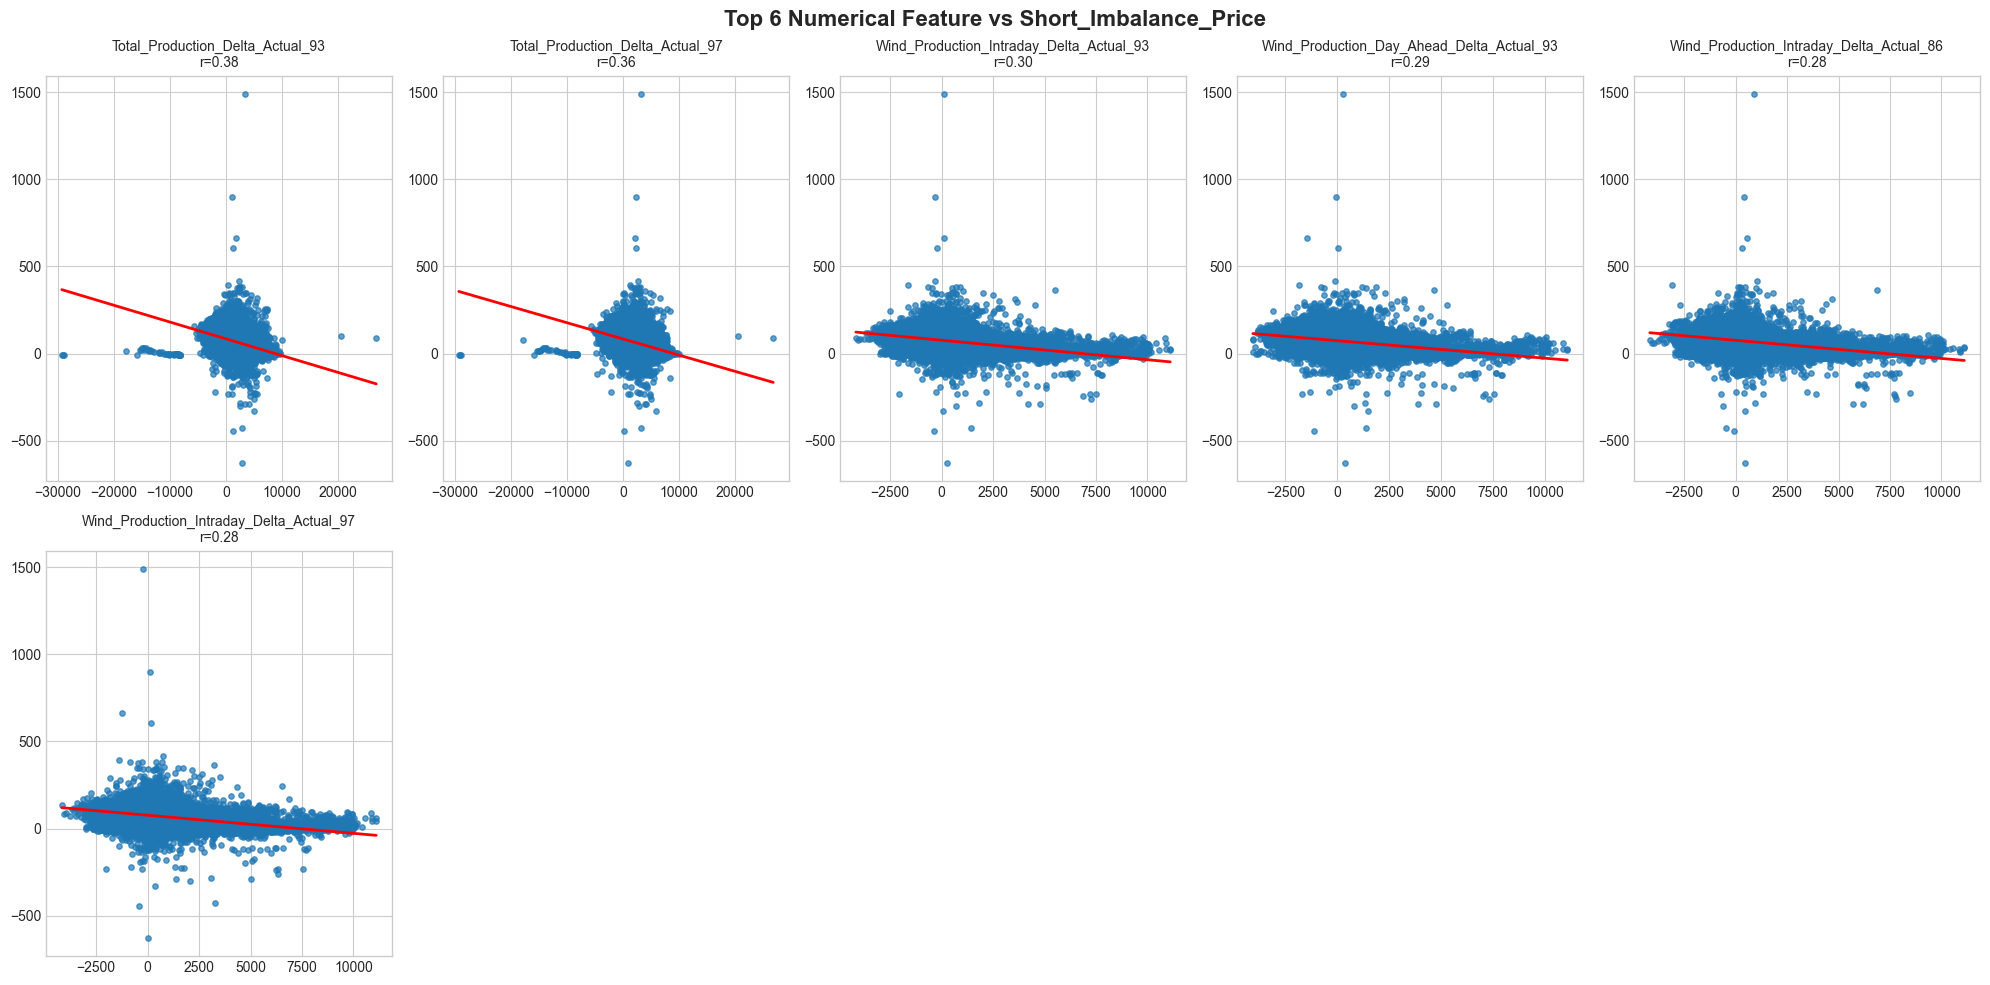

In [30]:
plot_top_correlated_features(data, target="Short_Imbalance_Price", nb_features=6, subset=lagged_features)